In [47]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
import matplotlib.gridspec as gridspec


In [2]:
data_dir = '/Users/rebekahzhang/data/behavior_data'
exp = 'exp2'
data_folder = os.path.join(data_dir, exp)
figure_folder = os.path.join(data_dir, 'timing_anchor_cv')
os.makedirs(figure_folder, exist_ok=True)

In [3]:
trials_training = pd.read_csv(os.path.join(data_folder, 'trials_cleaned.csv'))
print(trials_training.shape)
trials_training.head(3)

(593721, 81)


,session_trial_num,block_trial_num,block_num,start_time,end_time,bg_drawn,bg_length,bg_repeats,num_bg_licks,bg_repeat_rate,...,reward_rate_past_10min_in_block,cumulative_reward,group,dir,mouse,date,time,avg_tw,session,period
0,0.0,0.0,0.0,1.706626e+09,1.706626e+09,1.2,1.217297,1,1,0.821492,...,0.0,0.0,s,2024-01-30_09-52-34_RZ034,RZ034,2024-01-30,09-52-34,0.47,0,0
1,1.0,1.0,0.0,1.706626e+09,1.706626e+09,1.2,7.525090,12,13,1.727554,...,0.0,0.0,s,2024-01-30_09-52-34_RZ034,RZ034,2024-01-30,09-52-34,0.47,0,0
2,2.0,2.0,0.0,1.706626e+09,1.706626e+09,1.2,1.299892,1,1,0.769295,...,0.0,0.0,s,2024-01-30_09-52-34_RZ034,RZ034,2024-01-30,09-52-34,0.47,0,0


## BG length distribution by group

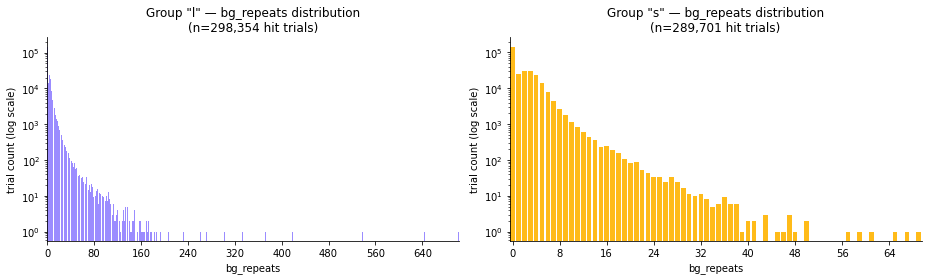

In [4]:
all_hit_trials = trials_training[~trials_training['miss_trial']].copy()
group_palette = {'s': '#ffb400', 'l': '#9080ff'}
groups = sorted(all_hit_trials['group'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, grp in zip(axes, groups):
    g = all_hit_trials[all_hit_trials['group'] == grp]['bg_repeats'].dropna()
    color = group_palette[grp]

    counts = g.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, width=0.8, alpha=0.9)
    ax.set_yscale('log')
    ax.set_xlabel('bg_repeats')
    ax.set_ylabel('trial count (log scale)')
    ax.set_title(f'Group "{grp}" — bg_repeats distribution\n(n={len(g):,} hit trials)')
    ax.set_xlim(-0.5, counts.index.max() + 0.5)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'bg_repeats_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

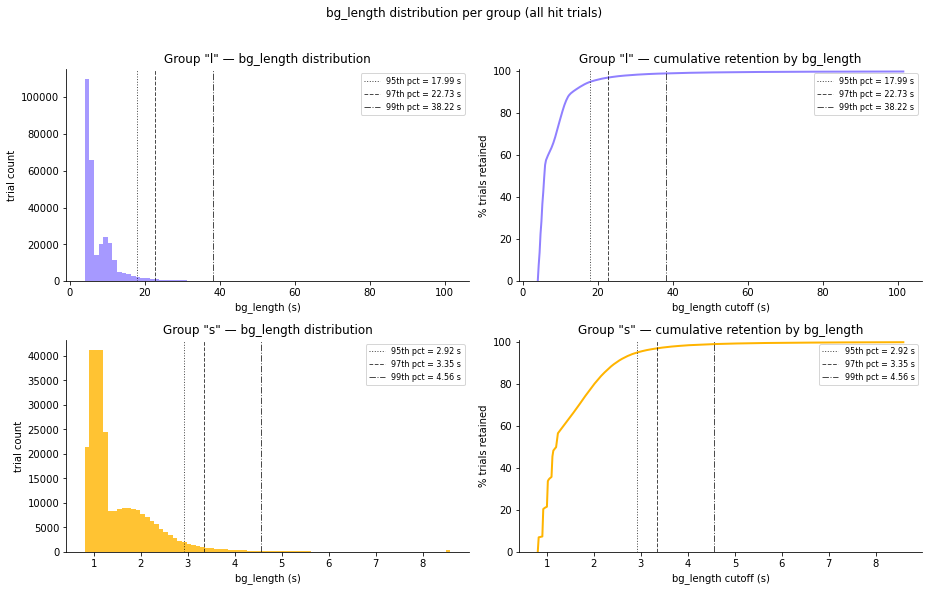

bg_length percentiles by group:
  Group 'l':  median=5.72s  95th=17.99s  97th=22.73s  99th=38.22s  max=888.69s
  Group 's':  median=1.20s  95th=2.92s  97th=3.35s  99th=4.56s  max=480.76s


In [5]:
# bg_length distribution per group — more direct proxy of the penalty the animal experienced
# (bg_length = bg_drawn + total restart penalty from bg licks)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, grp in enumerate(groups):
    grp_data = all_hit_trials[all_hit_trials['group'] == grp].dropna(subset=['bg_length'])
    color = group_palette[grp]
    n_total = len(grp_data)

    x_cap = grp_data['bg_length'].quantile(0.999)
    bins  = np.linspace(grp_data['bg_length'].min(), x_cap, 80)

    # Left: histogram
    ax = axes[row, 0]
    ax.hist(grp_data['bg_length'].clip(upper=x_cap), bins=bins, color=color, alpha=0.8)
    for pct, ls in [(95, ':'), (97, '--'), (99, '-.')]:
        v = grp_data['bg_length'].quantile(pct / 100)
        ax.axvline(v, color='black', lw=1, linestyle=ls, alpha=0.7, label=f'{pct}th pct = {v:.2f} s')
    ax.set_xlabel('bg_length (s)')
    ax.set_ylabel('trial count')
    ax.set_title(f'Group "{grp}" — bg_length distribution')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

    # Right: cumulative % retained as bg_length cutoff varies
    ax = axes[row, 1]
    x_vals  = np.linspace(grp_data['bg_length'].min(), x_cap, 400)
    cum_pct = [(grp_data['bg_length'] <= v).sum() / n_total * 100 for v in x_vals]
    ax.plot(x_vals, cum_pct, color=color, lw=2)
    for pct, ls in [(95, ':'), (97, '--'), (99, '-.')]:
        v = grp_data['bg_length'].quantile(pct / 100)
        ax.axvline(v, color='black', lw=1, linestyle=ls, alpha=0.7, label=f'{pct}th pct = {v:.2f} s')
    ax.set_xlabel('bg_length cutoff (s)')
    ax.set_ylabel('% trials retained')
    ax.set_title(f'Group "{grp}" — cumulative retention by bg_length')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 101)
    sns.despine(ax=ax)

fig.suptitle('bg_length distribution per group (all hit trials)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'bg_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("bg_length percentiles by group:")
for grp in groups:
    g = all_hit_trials[all_hit_trials['group'] == grp]['bg_length'].dropna()
    print(f"  Group '{grp}':  "
          f"median={g.median():.2f}s  "
          f"95th={g.quantile(0.95):.2f}s  "
          f"97th={g.quantile(0.97):.2f}s  "
          f"99th={g.quantile(0.99):.2f}s  "
          f"max={g.max():.2f}s")

## Timing references

Each column measures how long the mouse waited, measured from a different candidate anchor point.
We want the anchor that produces the **lowest CV** (= std / mean) across trials within a session —
that's the reference the animal's internal clock is most tightly locked to.

In [6]:
timing_refs = {
    'cue_on':        'time_waited_since_cue_on',
    'cue_off':       'time_waited',
    'last_reward':   'time_waited_since_last_reward',
    'last_lick':     'time_waited_since_last_lick',
    'last_lick_bout':'time_waited_since_last_lick_bout',
}

# Sanity check: which columns are actually present?
for label, col in timing_refs.items():
    present = col in trials_training.columns
    n_valid = trials_training[col].notna().sum() if present else 0
    print(f"  {label:16s} → {col:40s}  present={present}  n_valid={n_valid}")

  cue_on           → time_waited_since_cue_on                  present=True  n_valid=593721
  cue_off          → time_waited                               present=True  n_valid=593721
  last_reward      → time_waited_since_last_reward             present=True  n_valid=587912
  last_lick        → time_waited_since_last_lick               present=True  n_valid=593476
  last_lick_bout   → time_waited_since_last_lick_bout          present=True  n_valid=592785


## Filter trials

Only hit trials contribute a real wait time; miss trials are right-censored at 60 s.
Toggle `good_trial_only` to additionally exclude trials contaminated by background licks.

In [7]:
good_trial_only = False   # set True to exclude bg-lick trials

BG_REPEAT_CUTOFF = {'s': 7, 'l': 15}
MIN_TIME_SINCE_LICK = 0.5   # s; values below this are system errors

trials = trials_training[~trials_training['miss_trial']].copy()
if good_trial_only:
    trials = trials[trials['good_trial']]

n_before = len(trials)

# Filter 1: bg_length below 97th percentile per group
bg_len_p97 = trials.groupby('group')['bg_length'].transform(lambda x: x.quantile(0.97))
trials = trials[trials['bg_length'] <= bg_len_p97]
n_after_bg_len = len(trials)

# Filter 2: bg_repeats below cutoff per group
repeat_cutoff = trials['group'].map(BG_REPEAT_CUTOFF)
trials = trials[trials['bg_repeats'] <= repeat_cutoff]
n_after_repeats = len(trials)

# Filter 3: remove system-error trials (either anchor time < 0.5 s)
mask_lick      = trials['time_waited_since_last_lick'].notna()      & (trials['time_waited_since_last_lick']      < MIN_TIME_SINCE_LICK)
mask_lick_bout = trials['time_waited_since_last_lick_bout'].notna() & (trials['time_waited_since_last_lick_bout'] < MIN_TIME_SINCE_LICK)
trials = trials[~(mask_lick | mask_lick_bout)]
n_after_anchor = len(trials)

print("bg_length 97th pct cutoffs per group:")
cutoffs = trials_training[~trials_training['miss_trial']].groupby('group')['bg_length'].quantile(0.97)
for grp, v in cutoffs.items():
    print(f"  group '{grp}': {v:.2f} s")

print(f"\nbg_repeats cutoffs: {BG_REPEAT_CUTOFF}")
print(f"anchor time minimum: {MIN_TIME_SINCE_LICK} s")

print(f"\nStarting trials:                {n_before:,}")
print(f"After bg_length filter:         {n_after_bg_len:,}  (dropped {n_before - n_after_bg_len:,}, {(n_before - n_after_bg_len)/n_before:.1%})")
print(f"After bg_repeats filter:        {n_after_repeats:,}  (dropped {n_after_bg_len - n_after_repeats:,}, {(n_after_bg_len - n_after_repeats)/n_before:.1%})")
print(f"After anchor time filter:       {n_after_anchor:,}  (dropped {n_after_repeats - n_after_anchor:,}, {(n_after_repeats - n_after_anchor)/n_before:.1%})")
print(f"\n{n_after_anchor:,} hit trials remaining  ({trials['dir'].nunique()} sessions)")

bg_length 97th pct cutoffs per group:
  group 'l': 22.73 s
  group 's': 3.35 s

bg_repeats cutoffs: {'s': 7, 'l': 15}
anchor time minimum: 0.5 s

Starting trials:                588,055
After bg_length filter:         570,413  (dropped 17,642, 3.0%)
After bg_repeats filter:        561,274  (dropped 9,139, 1.6%)
After anchor time filter:       559,266  (dropped 2,008, 0.3%)

559,266 hit trials remaining  (1566 sessions)


In [8]:
# Descriptive stats for raw wait times per reference × group
rows = []
for label, col in timing_refs.items():
    if col not in trials.columns:
        continue
    for grp, grp_df in trials.groupby('group'):
        t = grp_df[col].dropna()
        rows.append(dict(
            reference=label,
            group=grp,
            n=len(t),
            mean=t.mean(),
            median=t.median(),
            std=t.std(),
            p25=t.quantile(0.25),
            p75=t.quantile(0.75),
        ))

wait_stats = pd.DataFrame(rows).set_index(['reference', 'group']).round(3)
print(wait_stats.to_string())

                           n    mean  median     std     p25     p75
reference      group                                                
cue_on         l      282817  10.588   9.048   6.437   6.625  12.306
               s      276449   3.383   2.703   3.179   1.871   3.895
cue_off        l      282817   3.466   1.682   6.034   0.825   3.499
               s      276449   1.985   1.203   3.169   0.557   2.325
last_reward    l      280438  36.876  25.115  37.684  14.080  44.646
               s      274023  19.748  14.231  18.552   7.647  24.960
last_lick      l      282729  10.378   7.856  14.888   6.417   9.836
               s      276301   3.913   2.970   5.828   1.949   4.551
last_lick_bout l      282465  14.372   8.243  34.536   6.618  11.501
               s      275893   6.774   3.409  34.468   2.141   5.377


## Compute CV per session × reference

In [9]:
def cv(x):
    """Coefficient of variation; NaN if fewer than 3 valid observations."""
    x = x.dropna()
    if len(x) < 3 or x.mean() == 0:
        return np.nan
    return x.std() / x.mean()

cv_rows = []
for label, col in timing_refs.items():
    if col not in trials.columns:
        continue
    per_session = (
        trials.groupby(['dir', 'mouse', 'group'])[col]
        .apply(cv)
        .reset_index()
        .rename(columns={col: 'cv'})
    )
    per_session['reference'] = label
    cv_rows.append(per_session)

session_cvs = pd.concat(cv_rows, ignore_index=True)

stats = (
    session_cvs
    .groupby(['reference', 'group'])['cv']
    .describe()
    .round(3)
)
print(stats.to_string())

                      count   mean    std    min    25%    50%    75%    max
reference      group                                                        
cue_off        l      884.0  1.379  0.393  0.589  1.060  1.339  1.661  2.806
               s      682.0  1.079  0.423  0.374  0.793  0.929  1.258  3.597
cue_on         l      884.0  0.544  0.133  0.286  0.428  0.523  0.645  0.875
               s      682.0  0.672  0.268  0.301  0.482  0.571  0.797  1.829
last_lick      l      884.0  0.999  0.605  0.183  0.407  0.935  1.525  2.577
               s      682.0  0.788  0.592  0.231  0.439  0.549  0.897  3.937
last_lick_bout l      884.0  1.069  0.618  0.195  0.579  0.989  1.501  4.861
               s      682.0  0.958  0.714  0.279  0.512  0.796  1.101  9.431
last_reward    l      884.0  0.888  0.212  0.468  0.739  0.854  0.994  2.795
               s      682.0  0.822  0.210  0.486  0.721  0.778  0.847  3.034


In [10]:
# Build session-level CV pivot (used by all subsequent CV analyses)
ref_order = list(timing_refs.keys())

cv_pivot = session_cvs.pivot_table(index='dir', columns='reference', values='cv')
cv_pivot = cv_pivot[ref_order]   # enforce column order

cv_pivot['best_ref'] = cv_pivot.idxmin(axis=1)

# Attach group info
dir_to_group = session_cvs[['dir', 'group']].drop_duplicates().set_index('dir')['group']
cv_pivot['group'] = cv_pivot.index.map(dir_to_group)

## Plots

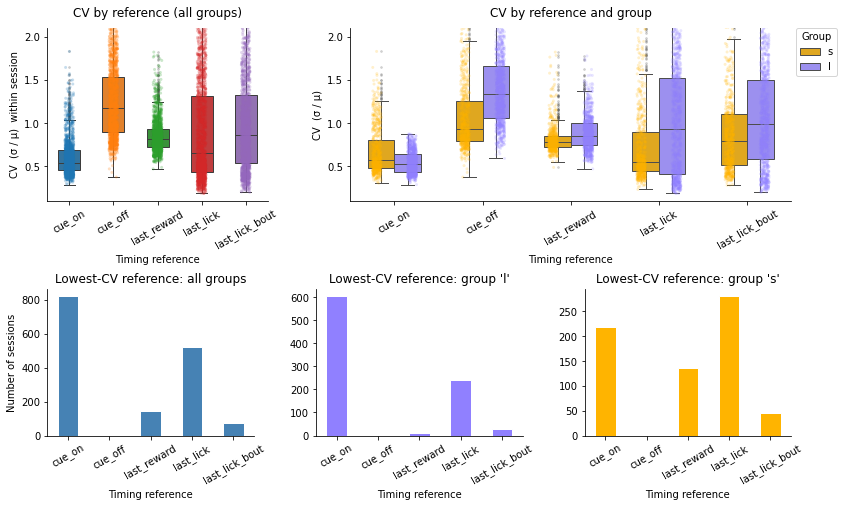

In [58]:
ref_order = list(timing_refs.keys())
y_cap = session_cvs['cv'].quantile(0.95)
groups = sorted(cv_pivot['group'].dropna().unique())
group_palette = {'s': '#ffb400', 'l': '#9080ff'}

fig = plt.figure(figsize=(13.33, 7.5))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 0.85], hspace=0.55, wspace=0.25, width_ratios=[1, 2])

# --- Top left: CV by reference (all groups) ---
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=session_cvs, x='reference', y='cv',
    order=ref_order, hue='reference', legend=False,
    palette='tab10', width=0.5,
    flierprops=dict(marker='.', markersize=3, alpha=0.3),
    ax=ax1
)
sns.stripplot(
    data=session_cvs, x='reference', y='cv',
    order=ref_order, hue='reference', legend=False,
    palette='tab10', size=3, alpha=0.25, jitter=True,
    ax=ax1
)
ax1.set_xlabel('Timing reference')
ax1.set_ylabel('CV  (σ / μ)  within session')
ax1.set_ylim(0.1, y_cap * 1.1) 
ax1.set_title('CV by reference (all groups)', y=1.03)
ax1.tick_params(axis='x', rotation=30)
sns.despine(ax=ax1)

# --- Top right: CV by reference × group ---
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(
    data=session_cvs, x='reference', y='cv', hue='group',
    order=ref_order, hue_order=['s', 'l'],
    palette=group_palette,
    width=0.6, flierprops=dict(marker='.', markersize=3, alpha=0.3),
    ax=ax2
)
sns.stripplot(
    data=session_cvs, x='reference', y='cv', hue='group',
    order=ref_order, hue_order=['s', 'l'],
    palette=group_palette,
    size=3, alpha=0.2, jitter=True, dodge=True, legend=False,
    ax=ax2
)
ax2.set_xlabel('Timing reference')
ax2.set_ylabel('CV  (σ / μ)')
ax2.set_ylim(0.1, y_cap * 1.1)    
ax2.set_title('CV by reference and group', y=1.03)
ax2.legend(title='Group', loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax2.tick_params(axis='x', rotation=30)
sns.despine(ax=ax2)

# --- Bottom row: Winner counts ---
n_groups = len(groups)
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, n_groups + 1, subplot_spec=gs[1, :], wspace=0.3)

winner_counts = cv_pivot['best_ref'].value_counts()

# All-groups panel
ax_all = fig.add_subplot(gs_bottom[0])
winner_counts.reindex(ref_order).plot.bar(
    ax=ax_all, color='steelblue', edgecolor='white')
ax_all.set_xlabel('Timing reference', fontsize=10)
ax_all.set_ylabel('Number of sessions', fontsize=10)
ax_all.set_title('Lowest-CV reference: all groups')
ax_all.tick_params(axis='x', rotation=30)
sns.despine(ax=ax_all)

# Per-group panels
for i, grp in enumerate(groups):
    ax_grp = fig.add_subplot(gs_bottom[i + 1])
    wc = cv_pivot[cv_pivot['group'] == grp]['best_ref'].value_counts()
    wc.reindex(ref_order).plot.bar(
        ax=ax_grp, color=group_palette.get(grp, 'steelblue'), edgecolor='white')
    ax_grp.set_xlabel('Timing reference', fontsize=10)
    ax_grp.set_ylabel('')
    ax_grp.set_title(f"Lowest-CV reference: group '{grp}'")
    ax_grp.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax_grp)


plt.savefig(os.path.join(figure_folder, 'cv_analysis_combined.png'), dpi=150, bbox_inches='tight')

## Mouse-level summary

Aggregate across sessions per mouse to see if individual animals favour different anchors.

Best reference per mouse:
reference group     best_ref
mouse                       
RZ037         l       cue_on
RZ065         l       cue_on
RZ056         l       cue_on
RZ068         l       cue_on
RZ052         l       cue_on
RZ053         l       cue_on
RZ058         l       cue_on
RZ039         l       cue_on
RZ082         l       cue_on
RZ081         l       cue_on
RZ075         l       cue_on
RZ059         l       cue_on
RZ057         l       cue_on
RZ067         l       cue_on
RZ055         l       cue_on
RZ054         l       cue_on
RZ074         l       cue_on
RZ083         s       cue_on
RZ034         s    last_lick
RZ051         s    last_lick
RZ036         s    last_lick
RZ050         s       cue_on
RZ085         s       cue_on
RZ063         s    last_lick
RZ062         s       cue_on
RZ064         s       cue_on
RZ072         s    last_lick
RZ061         s    last_lick
RZ070         s    last_lick
RZ047         s    last_lick
RZ069         s  last_reward


/var/folders/fv/h96g2bdx42l2htl2pxpvr84h0000gn/T/ipykernel_4376/106707152.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


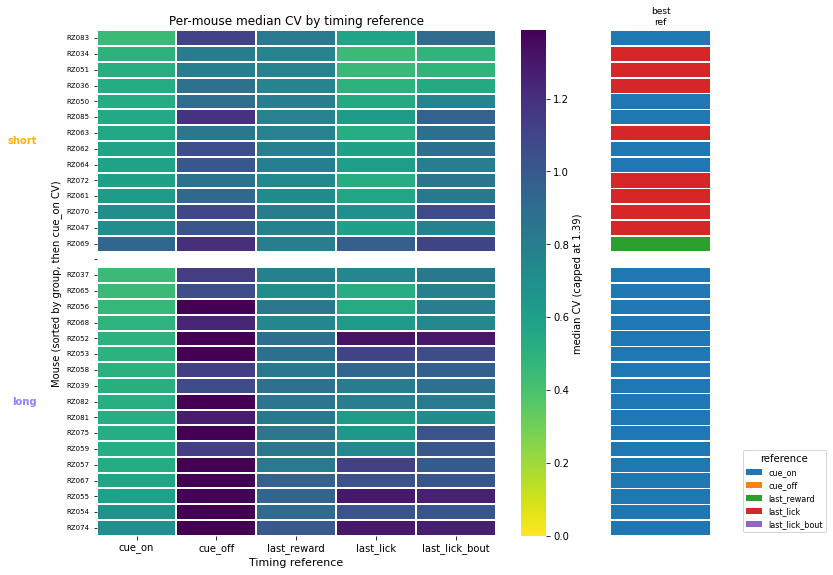

In [59]:
mouse_cv = (
    session_cvs
    .groupby(['mouse', 'group', 'reference'])['cv']
    .median()
    .reset_index()
    .rename(columns={'cv': 'median_cv'})
)

mouse_pivot = mouse_cv.pivot_table(index='mouse', columns='reference', values='median_cv')
mouse_pivot['best_ref'] = mouse_pivot[ref_order].idxmin(axis=1)

# Add group label for sorting
mouse_group = session_cvs[['mouse', 'group']].drop_duplicates().set_index('mouse')['group']
mouse_pivot['group'] = mouse_pivot.index.map(mouse_group)

# Sort: group first, then by cue_on CV within group
mouse_pivot = mouse_pivot.sort_values(['group', 'cue_on'])

print("Best reference per mouse:")
print(mouse_pivot[['group', 'best_ref']].to_string())

# Cap colorscale
vmax = mouse_pivot[ref_order].stack().quantile(0.95)

# Scale figure height so every mouse label fits
n_mice = len(mouse_pivot)
fig_h = max(7, n_mice * 0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, fig_h),
                         gridspec_kw={'width_ratios': [5, 1], 'wspace': 0.05})

# Left: heatmap
ax = axes[0]
s_mice = mouse_pivot[mouse_pivot['group'] == 's'][ref_order]
l_mice = mouse_pivot[mouse_pivot['group'] == 'l'][ref_order]
gap = pd.DataFrame([[np.nan] * len(ref_order)], columns=ref_order, index=[''])
heat_data = pd.concat([s_mice, gap, l_mice])

sns.heatmap(
    heat_data, cmap='viridis_r', ax=ax,
    vmin=0, vmax=vmax,
    yticklabels=1,   # show every row label
    cbar_kws={'label': f'median CV (capped at {vmax:.2f})'},
    linewidths=0.3, linecolor='white'
)
ax.set_xlabel('Timing reference', fontsize=11)
ax.set_ylabel('Mouse (sorted by group, then cue_on CV)', fontsize=10)
ax.set_title('Per-mouse median CV by timing reference', fontsize=12)
ax.tick_params(axis='y', labelsize=7)

# Add group labels on y-axis
n_s = len(s_mice)
n_l = len(l_mice)
ax.axhline(n_s, color='white', lw=3)
ax.text(-0.15, n_s / 2, 'short', va='center', ha='right',
        fontsize=10, color='#ffb400', fontweight='bold', transform=ax.get_yaxis_transform())
ax.text(-0.15, n_s + 1 + n_l / 2, 'long', va='center', ha='right',
        fontsize=10, color='#9080ff', fontweight='bold', transform=ax.get_yaxis_transform())

# Right: best_ref bar coloured by reference
ax2 = axes[1]
best_data = pd.concat([
    mouse_pivot[mouse_pivot['group'] == 's'][['best_ref']],
    pd.DataFrame([['gap']], columns=['best_ref'], index=['']),
    mouse_pivot[mouse_pivot['group'] == 'l'][['best_ref']]
])
ref_colors = dict(zip(ref_order, sns.color_palette('tab10', len(ref_order))))
bar_colors = [ref_colors.get(r, 'white') for r in best_data['best_ref']]
ax2.barh(range(len(best_data)), [1] * len(best_data), color=bar_colors, height=0.9)
ax2.invert_yaxis()
ax2.set_xlim(0, 1)
ax2.set_ylim(len(best_data) - 0.5, -0.5)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title('best\nref', fontsize=9)

legend_elements = [Patch(facecolor=ref_colors[r], label=r) for r in ref_order]
ax2.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(2.2, 0), fontsize=8, title='reference')
sns.despine(ax=ax2, left=True, bottom=True)

plt.savefig(os.path.join(figure_folder, 'mouse_cv_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Session-level heatmap

Each row is a session; color = CV.  Sessions sorted by cue_off CV so patterns are easier to spot.

Spearman correlation with bin rank (positive = darker → lighter = CV rises with cue_off CV):
  cue_on            r = 0.972
  cue_off           r = 1.000
  last_reward       r = 0.844
  last_lick         r = 0.978
  last_lick_bout    r = 0.961



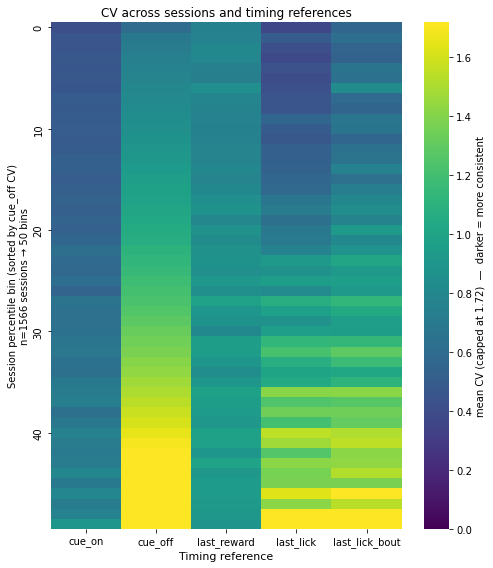

In [15]:
N_BINS = 50   # number of session percentile bins

heat_data = cv_pivot[ref_order].sort_values('cue_off').reset_index(drop=True)

# Bin sorted sessions into N_BINS equal groups, take the mean CV per bin
heat_data['bin'] = pd.cut(heat_data.index, bins=N_BINS, labels=False)
heat_binned = heat_data.groupby('bin')[ref_order].mean()

# Cap colour scale at 95th percentile so a few large-CV sessions don't wash out the palette
vmax = heat_binned.stack().quantile(0.95)

# Summarise trend: correlation of each reference with bin rank
print("Spearman correlation with bin rank (positive = darker → lighter = CV rises with cue_off CV):")
for ref in ref_order:
    r = heat_binned[ref].dropna().rank().corr(
        pd.Series(range(len(heat_binned[ref].dropna())), index=heat_binned[ref].dropna().index),
        method='spearman'
    )
    print(f"  {ref:16s}  r = {r:.3f}")
print()

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(
    heat_binned, cmap='viridis', ax=ax,
    vmin=0, vmax=vmax,
    cbar_kws={'label': f'mean CV (capped at {vmax:.2f})  —  darker = more consistent'},
    yticklabels=10   # label every 10th bin (= every 20th percentile)
)
ax.set_xlabel('Timing reference', fontsize=11)
ax.set_ylabel(f'Session percentile bin (sorted by cue_off CV)\nn={len(heat_data)} sessions → {N_BINS} bins', fontsize=10)
ax.set_title('CV across sessions and timing references', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'cv_heatmap.png'), dpi=150)
plt.show()

What the analysis is trying to show <br>
are some sessions just harder to time in general, regardless of which reference point you use? Or does the CV of each reference reflect something specific to that reference? <br>
The trick is sorting sessions by cue_off CV from low to high, then asking: as cue_off CV increases (moving down the rows), what happens to the CV of the other references? <br>
If all references rise together as cue_off rises, it means high-CV sessions are globally noisy — something about those sessions (disengagement, satiety, early training) makes all timing references messy simultaneously. The reference ordering doesn't matter much; you're just capturing session quality. <br>
If one reference stays flat while others rise, that reference is tracking something independent of session-level noise — it's genuinely more consistent regardless of how hard the session is. <br>

What the results tell you <br>
The Spearman correlations are all extremely high: cue_on=0.961, last_lick=0.947, last_lick_bout=0.930, last_reward=0.919. <br>
Every reference rises almost perfectly in lockstep with cue_off CV.<br>
The binned table confirms this — look at cue_on across bins: it goes from ~0.41 in bin 0 to ~0.93 in bin 49. Same monotone rise as cue_off, just at lower absolute values throughout. <br>
This tells you that most of the variance in CV across sessions is session-level variance, not reference-specific variance. <br>
Good sessions are good for all references; bad sessions are bad for all references.<br>
The implication for your reference point selection: you can't use CV alone to select a winner, because all references are confounded by session quality. The reason cue_on has the lowest absolute CV isn't because it's the best timing reference — it's because it has the smallest dynamic range in the task and is least sensitive to session-level noise. This is exactly why the hazard analysis was necessary and why it gave you a different answer. <br>
The one useful thing this analysis does tell you: the CV of any single reference is a reasonable proxy for session quality. You could use, say, cue_off CV or last_lick CV as a session-level quality metric for your outlier exclusion — high CV sessions are globally noisy sessions, and that's meaningful regardless of mechanism. <br>

Spearman correlation with bin rank:
  cue_on            r = 0.938
  cue_off           r = 1.000
  last_reward       r = 0.712
  last_lick         r = 0.944
  last_lick_bout    r = 0.937

Spearman correlation with bin rank:
  cue_on            r = 0.981
  cue_off           r = 1.000
  last_reward       r = 0.717
  last_lick         r = 0.957
  last_lick_bout    r = 0.895



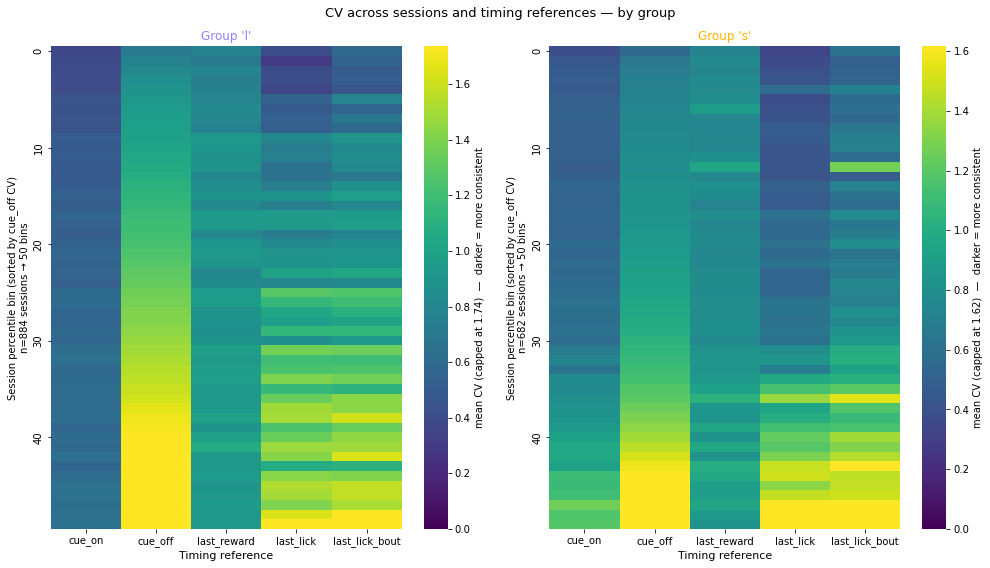

In [16]:
N_BINS = 50

groups = sorted(cv_pivot['group'].dropna().unique())
group_palette = {'s': '#ffb400', 'l': '#9080ff'}

fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 8), sharey=False)

for ax, grp in zip(axes, groups):
    grp_pivot = cv_pivot[cv_pivot['group'] == grp][ref_order]
    heat_data_g = grp_pivot.sort_values('cue_off').reset_index(drop=True)
    heat_data_g['bin'] = pd.cut(heat_data_g.index, bins=N_BINS, labels=False)
    heat_binned_g = heat_data_g.groupby('bin')[ref_order].mean()
    vmax_g = heat_binned_g.stack().quantile(0.95)

    print("Spearman correlation with bin rank:")
    for ref in ref_order:
        col = heat_binned_g[ref].dropna()
        r = col.rank().corr(
            pd.Series(range(len(col)), index=col.index),
            method='spearman'
        )
        print(f"  {ref:16s}  r = {r:.3f}")
    print()

    sns.heatmap(
        heat_binned_g, cmap='viridis', ax=ax,
        vmin=0, vmax=vmax_g,
        cbar_kws={'label': f'mean CV (capped at {vmax_g:.2f})  —  darker = more consistent'},
        yticklabels=10
    )
    ax.set_xlabel('Timing reference', fontsize=11)
    ax.set_ylabel(f'Session percentile bin (sorted by cue_off CV)\nn={len(grp_pivot)} sessions → {N_BINS} bins', fontsize=10)
    ax.set_title(f"Group '{grp}'", fontsize=12, color=group_palette.get(grp, 'black'))

fig.suptitle('CV across sessions and timing references — by group', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'cv_heatmap_by_group.png'), dpi=150)
plt.show()

## CV vs. bg_length

Does the "winning" reference depend on how long the background period was? <br>

Group 'l'
  mean_bg_length range: 5.01 – 11.74 s

  reference            slope   intercept   spearman_r   median_cv
  cue_on              -0.032       0.768       -0.227       0.523
  cue_off              0.080       0.741        0.278       1.279
  last_reward         -0.019       1.022       -0.044       0.853
  last_lick           -0.062       1.337       -0.139       0.833
  last_lick_bout      -0.069       1.416       -0.179       0.876

Group 's'
  mean_bg_length range: 1.04 – 1.85 s

  reference            slope   intercept   spearman_r   median_cv
  cue_on              -0.539       1.404       -0.412       0.571
  cue_off             -0.009       1.028        0.004       0.911
  last_reward         -0.098       0.946        0.071       0.778
  last_lick           -0.464       1.295       -0.159       0.526
  last_lick_bout      -0.358       1.283       -0.139       0.750



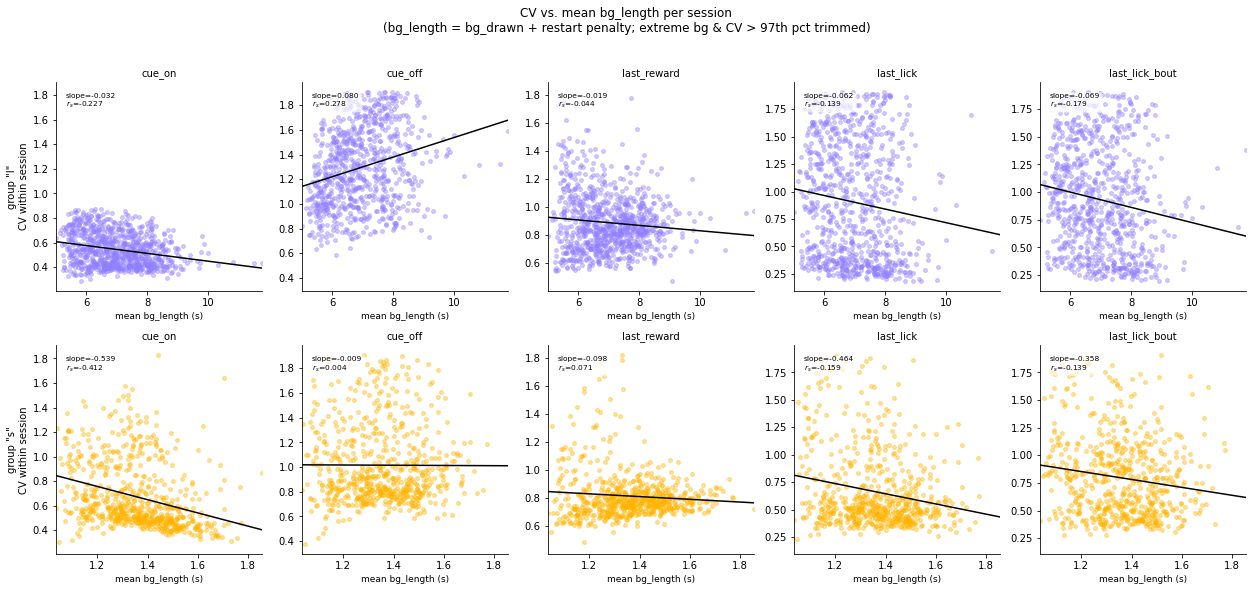

In [17]:

# bg_length = actual experienced delay (bg_drawn + restart penalty from bg licks)
bg_per_session = (
    trials.groupby(['dir', 'group'])['bg_length']
    .mean()
    .reset_index()
    .rename(columns={'bg_length': 'mean_bg_length'})
)
cv_with_bg = session_cvs.merge(bg_per_session, on=['dir', 'group'], how='left')

groups = sorted(cv_with_bg['group'].dropna().unique())
group_palette = {'s': '#ffb400', 'l': '#9080ff'}
y_cap = cv_with_bg['cv'].quantile(0.95)
n_refs = len(timing_refs)

# Print values
for grp in groups:
    print(f"{'='*60}")
    print(f"Group '{grp}'")
    print(f"{'='*60}")
    grp_data = cv_with_bg[cv_with_bg['group'] == grp]
    print(f"  mean_bg_length range: {grp_data['mean_bg_length'].min():.2f} – {grp_data['mean_bg_length'].max():.2f} s\n")
    print(f"  {'reference':16s}  {'slope':>8}  {'intercept':>10}  {'spearman_r':>11}  {'median_cv':>10}")
    for label, _ in timing_refs.items():
        sub = grp_data[grp_data['reference'] == label].dropna(subset=['cv', 'mean_bg_length'])
        sub = sub[sub['cv'] <= y_cap]
        m, b = np.polyfit(sub['mean_bg_length'], sub['cv'], 1)
        r = sub['mean_bg_length'].corr(sub['cv'], method='spearman')
        med = sub['cv'].median()
        print(f"  {label:16s}  {m:>8.3f}  {b:>10.3f}  {r:>11.3f}  {med:>10.3f}")
    print()

fig, axes = plt.subplots(
    len(groups), n_refs,
    figsize=(3.5 * n_refs, 4 * len(groups)),
    sharey='col',
    sharex='row',
)

for row, grp in enumerate(groups):
    grp_data = cv_with_bg[cv_with_bg['group'] == grp]
    color = group_palette.get(grp, 'gray')

    x_min = grp_data['mean_bg_length'].min()
    x_max = grp_data['mean_bg_length'].max()

    for col, (label, _) in enumerate(timing_refs.items()):
        ax = axes[row, col]
        sub = grp_data[grp_data['reference'] == label].dropna(subset=['cv', 'mean_bg_length'])
        sub = sub[sub['cv'] <= y_cap]
        ax.scatter(sub['mean_bg_length'], sub['cv'], alpha=0.4, s=15, color=color)
        if len(sub) > 5:
            m, b = np.polyfit(sub['mean_bg_length'], sub['cv'], 1)
            r = sub['mean_bg_length'].corr(sub['cv'], method='spearman')
            xr = np.linspace(x_min, x_max, 50)
            ax.plot(xr, m * xr + b, color='black', lw=1.5)
            ax.text(0.05, 0.95,
                    f'slope={m:.3f}\n$r_s$={r:.3f}',
                    transform=ax.transAxes,
                    fontsize=7.5, va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='none'))
        ax.set_xlim(x_min, x_max)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('mean bg_length (s)', fontsize=9)
        if col == 0:
            ax.set_ylabel(f'group "{grp}"\nCV within session', fontsize=10)
        sns.despine(ax=ax)

fig.suptitle('CV vs. mean bg_length per session\n'
             '(bg_length = bg_drawn + restart penalty; extreme bg & CV > 97th pct trimmed)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'cv_vs_bg_length.png'), dpi=150, bbox_inches='tight')
plt.show()


Summary stats — time_waited (cue_off) by group × bg_repeats

Group 'l' (bg_repeats ≤ 15):
                 n   mean  median    std     cv  skewness  kurtosis
bg_repeats                                                         
0           147376  4.493   2.079  7.411  1.649     3.953    18.722
1            11441  3.390   1.830  5.451  1.608     5.082    34.363
2            14639  2.776   1.638  4.177  1.505     5.586    45.245
3            21479  2.483   1.535  3.853  1.552     7.094    72.812
4            24022  2.298   1.446  3.473  1.511     7.293    79.796
5            18363  2.240   1.416  3.340  1.491     7.018    73.785
6            12018  2.168   1.351  3.324  1.533     7.558    88.582
7             8185  2.073   1.258  3.173  1.530     6.702    67.755
8             6195  1.978   1.164  3.190  1.613     6.705    65.321
9             4717  1.894   1.106  3.085  1.628     7.101    77.647
10            3866  1.806   1.019  3.094  1.713     7.459    79.689
11            3111  1.778 

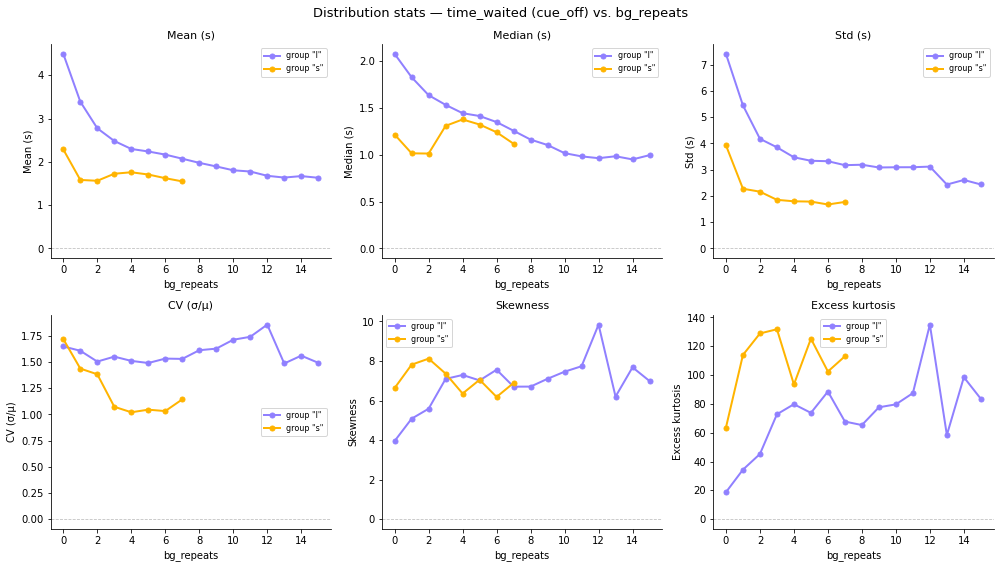

In [18]:
from scipy.stats import skew, kurtosis

BG_REPEAT_CUTOFF = {'s': 7, 'l': 15}

# --- Compute summary stats per (group, bg_repeats) ---
stats_rows = []
for grp in groups:
    cutoff = BG_REPEAT_CUTOFF[grp]
    g = (trials[trials['group'] == grp]
         .dropna(subset=['bg_repeats', 'time_waited'])
         .pipe(lambda df: df[df['bg_repeats'] <= cutoff]))
    for rep, sub in g.groupby('bg_repeats'):
        t = sub['time_waited'].values
        stats_rows.append({
            'group':      grp,
            'bg_repeats': int(rep),
            'n':          len(t),
            'mean':       np.mean(t),
            'median':     np.median(t),
            'std':        np.std(t),
            'cv':         np.std(t) / np.mean(t),
            'skewness':   skew(t),
            'kurtosis':   kurtosis(t),   # excess kurtosis (normal = 0)
        })

stats_df = pd.DataFrame(stats_rows)

print("Summary stats — time_waited (cue_off) by group × bg_repeats\n")
for grp in groups:
    cutoff = BG_REPEAT_CUTOFF[grp]
    print(f"Group '{grp}' (bg_repeats ≤ {cutoff}):")
    sub = stats_df[stats_df['group'] == grp].set_index('bg_repeats')
    print(sub[['n', 'mean', 'median', 'std', 'cv', 'skewness', 'kurtosis']].round(3).to_string())
    print()

# --- Plot stats vs bg_repeats ---
stat_cols   = ['mean',     'median',     'std',     'cv',       'skewness', 'kurtosis']
stat_labels = ['Mean (s)', 'Median (s)', 'Std (s)', 'CV (σ/μ)', 'Skewness', 'Excess kurtosis']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col, label in zip(axes, stat_cols, stat_labels):
    for grp in groups:
        sub = stats_df[stats_df['group'] == grp].sort_values('bg_repeats')
        ax.plot(sub['bg_repeats'], sub[col],
                color=group_palette[grp], marker='o', lw=2, ms=5, label=f'group "{grp}"')
    ax.axhline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('bg_repeats', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('Distribution stats — time_waited (cue_off) vs. bg_repeats', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_bg_repeats_stats.png'), dpi=150)
plt.show()

## CV vs. session number — does the timing anchor shift with training?

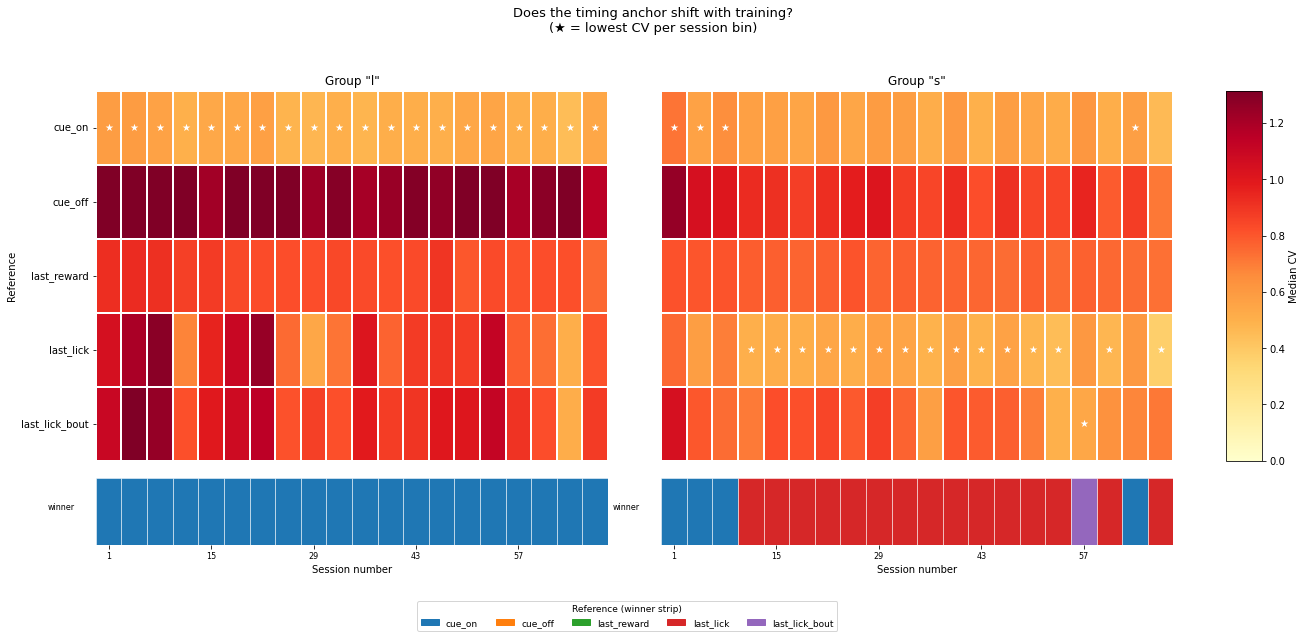

In [19]:
# Pull session number from trials (one value per dir)
session_num = (
    trials[['dir', 'session']].drop_duplicates()
    if 'session' in trials.columns
    else trials_training[['dir', 'session']].drop_duplicates()
)
cv_by_session = session_cvs.merge(session_num, on='dir', how='left')

N_SESSION_BINS = 20
cv_by_session['session_bin'] = pd.cut(
    cv_by_session['session'], bins=N_SESSION_BINS, labels=False
)
bin_edges = pd.cut(cv_by_session['session'], bins=N_SESSION_BINS, retbins=True)[1]
bin_mids  = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype(int)

# Median CV per session bin × reference × group
binned = (
    cv_by_session
    .groupby(['session_bin', 'reference', 'group'])['cv']
    .median()
    .reset_index()
)

groups        = sorted(binned['group'].dropna().unique())
group_palette = {'s': '#ffb400', 'l': '#9080ff'}
ref_colors    = dict(zip(ref_order, sns.color_palette('tab10', len(ref_order))))

vmax = binned['cv'].quantile(0.95)

from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

n_grp = len(groups)
fig = plt.figure(figsize=(8 * n_grp + 2, 9))
gs  = GridSpec(
    2, n_grp + 1,
    height_ratios=[5, 0.9],
    width_ratios=[5] * n_grp + [0.35],
    hspace=0.08, wspace=0.15,
    left=0.07, right=0.97, top=0.85, bottom=0.15,
)

for col_idx, grp in enumerate(groups):
    ax_heat   = fig.add_subplot(gs[0, col_idx])
    ax_winner = fig.add_subplot(gs[1, col_idx])

    grp_data = binned[binned['group'] == grp]
    pivot = (grp_data
             .pivot(index='reference', columns='session_bin', values='cv')
             .reindex(ref_order))
    pivot.columns = [bin_mids[int(b)] for b in pivot.columns]

    sns.heatmap(
        pivot, ax=ax_heat,
        cmap='YlOrRd', vmin=0, vmax=vmax,
        linewidths=0.4, linecolor='white',
        cbar=False,
    )

    # Star on the winning (lowest CV) reference per session bin
    winner_per_bin = pivot.idxmin(axis=0)
    for j, (sess, ref) in enumerate(winner_per_bin.items()):
        if pd.notna(ref):
            row_i = list(pivot.index).index(ref)
            ax_heat.text(j + 0.5, row_i + 0.5, '★',
                         ha='center', va='center',
                         color='white', fontsize=10, fontweight='bold')

    ax_heat.set_title(f'Group "{grp}"', fontsize=12)
    ax_heat.set_xlabel('')
    ax_heat.tick_params(axis='x', labelbottom=False, bottom=False)

    if col_idx == 0:
        ax_heat.set_ylabel('Reference', fontsize=10)
        ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0)
    else:
        ax_heat.set_ylabel('')
        ax_heat.set_yticklabels([])
        ax_heat.tick_params(axis='y', left=False)

    # Winner strip
    for j, (sess, ref) in enumerate(winner_per_bin.items()):
        color = ref_colors.get(ref, 'lightgray') if pd.notna(ref) else 'lightgray'
        ax_winner.bar(j + 0.5, 1, width=1, color=color,
                      edgecolor='white', linewidth=0.5, align='center')

    n_bins    = len(pivot.columns)
    tick_step = max(1, n_bins // 5)
    tick_pos  = list(range(0, n_bins, tick_step))
    ax_winner.set_xticks([p + 0.5 for p in tick_pos])
    ax_winner.set_xticklabels([pivot.columns[p] for p in tick_pos], fontsize=8)
    ax_winner.set_xlim(0, n_bins)
    ax_winner.set_ylim(0, 1)
    ax_winner.set_yticks([])
    ax_winner.set_xlabel('Session number', fontsize=10)
    ax_winner.set_ylabel('winner', fontsize=8, rotation=0, labelpad=35)
    sns.despine(ax=ax_winner, left=True, bottom=True)

# Shared colorbar in dedicated axes
ax_cbar = fig.add_subplot(gs[0, n_grp])
norm = plt.Normalize(vmin=0, vmax=vmax)
sm   = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=ax_cbar, label='Median CV')

# Reference legend at the bottom, spread horizontally so it doesn't crowd the colorbar
legend_patches = [Patch(color=ref_colors[r], label=r) for r in ref_order]
fig.legend(handles=legend_patches, title='Reference (winner strip)',
           loc='lower center', bbox_to_anchor=(0.48, 0.01),
           ncol=len(ref_order), fontsize=9, title_fontsize=9)

fig.suptitle('Does the timing anchor shift with training?\n(★ = lowest CV per session bin)',
             fontsize=13)
plt.savefig(os.path.join(figure_folder, 'cv_vs_session_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Hazard rate analysis

The **hazard rate** h(t) is the instantaneous leaving probability given the mouse has not yet left:

$$h(t) = \frac{f(t)}{S(t)}$$

where f(t) is the density of leaving times and S(t) = P(T > t) is the survival function.

- **Rising hazard** → the longer the mouse waits from this reference, the more likely it is to leave *right now* → it is actively timing from this anchor.
- **Flat hazard** → memoryless (exponential waiting) → not timing from this reference.
- **Falling hazard** → wait times front-loaded → also inconsistent with prospective timing.

We estimate h(t) using a Gaussian KDE for f̂(t) and the empirical survival function for Ŝ(t), pooled across all hit trials within each group. The Spearman ρ between h(t) and t summarises how steeply rising each curve is.

In [20]:
def kernel_hazard(times, t_grid, bw_method='scott'):
    """
    Kernel-smoothed hazard rate  h(t) = f̂(t) / Ŝ(t).

    f̂: Gaussian KDE of observed leave times.
    Ŝ: empirical survival = fraction of times > t (vectorised with searchsorted).

    All observations assumed uncensored (hit trials only).
    Returns NaN beyond the 95th percentile of the data.
    """
    times = np.asarray(times, dtype=float)
    times = times[np.isfinite(times) & (times > 0)]
    if len(times) < 20:
        return np.full(len(t_grid), np.nan)

    kde = gaussian_kde(times, bw_method=bw_method)
    f_hat = kde(t_grid)

    sorted_t = np.sort(times)
    # S(t) = fraction still waiting beyond t
    S_hat = 1.0 - np.searchsorted(sorted_t, t_grid, side='right') / len(times)
    S_hat = np.clip(S_hat, 1e-4, 1.0)

    h = f_hat / S_hat
    h[t_grid > np.quantile(times, 0.95)] = np.nan   # mask unreliable tail
    return h


BW = 0.03   # covariance_factor for gaussian_kde; smaller → sharper (Scott ≈ 0.05–0.07 for these n)
N_GRID = 400

ref_colors = dict(zip(ref_order, sns.color_palette('tab10', len(ref_order))))

# Pre-compute hazard curves for every (group, reference) pair
hazard_data = {}
for grp in groups:
    grp_trials = trials[trials['group'] == grp]
    for label, col in timing_refs.items():
        t = grp_trials[col].dropna().values
        t = t[(t > 0) & np.isfinite(t)]
        if len(t) < 100:
            hazard_data[(grp, label)] = (None, None)
            continue
        t_grid = np.linspace(0.01, np.quantile(t, 0.95), N_GRID)
        h = kernel_hazard(t, t_grid, bw_method=BW)
        hazard_data[(grp, label)] = (t_grid, h)

# Summary table: Spearman ρ(h, t) as a "rising hazard score"
print("Spearman ρ (hazard vs. time):  higher → more rising → stronger timing signal\n")
header = f"{'reference':20s}" + "".join(f"  group_{g}" for g in groups)
print(header)
print("-" * len(header))
for label in ref_order:
    row_str = f"{label:20s}"
    for grp in groups:
        tg, h = hazard_data.get((grp, label), (None, None))
        if h is None:
            row_str += f"  {'N/A':>7}"
        else:
            valid = np.isfinite(h)
            rho, _ = spearmanr(tg[valid], h[valid])
            row_str += f"  {rho:>7.3f}"
    print(row_str)

Spearman ρ (hazard vs. time):  higher → more rising → stronger timing signal

reference             group_l  group_s
--------------------------------------
cue_on                  0.620    0.329
cue_off                -0.949   -0.780
last_reward            -0.550   -0.358
last_lick               0.304    0.433
last_lick_bout         -0.302   -0.564


given the mouse hasn't licked yet, what's the instantaneous probability it licks right now? 
The Spearman ρ between h(t) and t summarizes the shape of the hazard curve into a single number: <br>
positive ρ means hazard rises over time, negative ρ means hazard falls, near-zero means flat (memoryless).

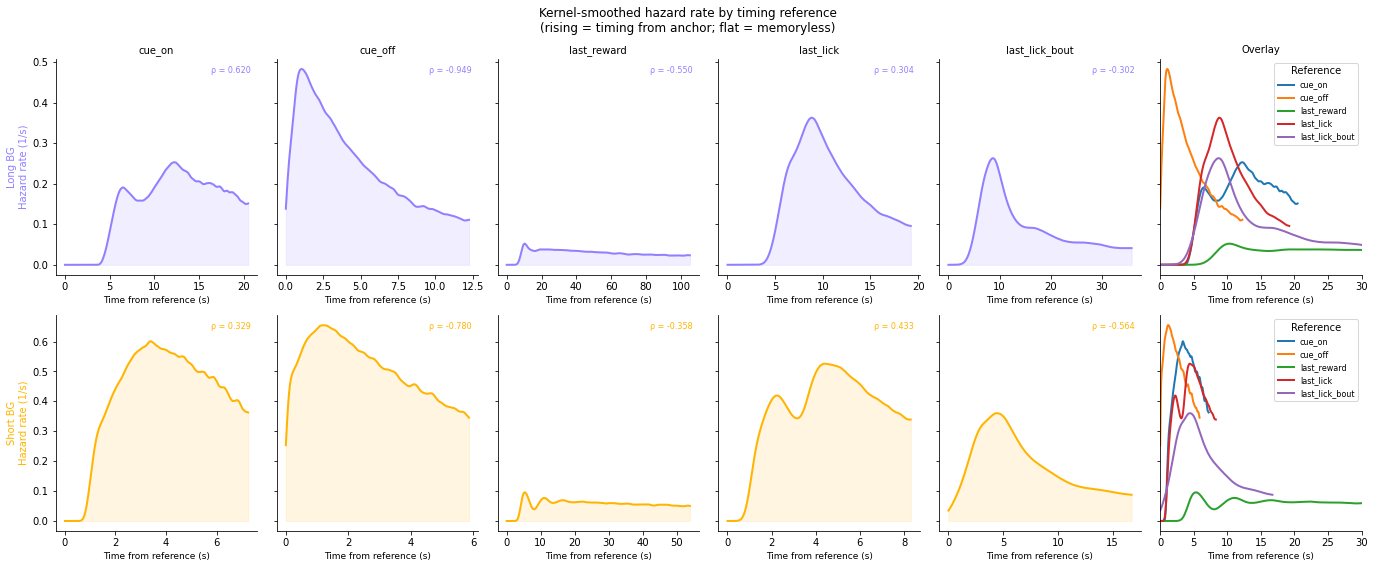

In [63]:
n_refs = len(ref_order)
n_cols = n_refs + 1  # Individual refs + overlay

fig, axes = plt.subplots(len(groups), n_cols,
                         figsize=(3.2 * n_cols, 4 * len(groups)),
                         sharey='row')

# Reorder groups so 'l' is on top, 's' on bottom
group_order = ['l', 's'] if set(groups) == {'l', 's'} else groups

for row, grp in enumerate(group_order):
    color = group_palette[grp]
    
    # --- Individual reference panels ---
    for col, label in enumerate(ref_order):
        ax = axes[row, col]
        tg, h = hazard_data.get((grp, label), (None, None))
        if tg is not None:
            valid = np.isfinite(h)
            ax.plot(tg[valid], h[valid], color=color, lw=2)
            ax.fill_between(tg[valid], h[valid], alpha=0.12, color=color)
            rho, _ = spearmanr(tg[valid], h[valid])
            ax.text(0.97, 0.97, f'ρ = {rho:.3f}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=8, color=color)
        ax.set_xlabel('Time from reference (s)', fontsize=9)
        if col == 0:
            grp_label = 'Long BG' if grp == 'l' else 'Short BG'
            ax.set_ylabel(f'{grp_label}\nHazard rate (1/s)', fontsize=10, color=color)
        ax.set_title(label, fontsize=10) if row == 0 else None
        sns.despine(ax=ax)
    
    # --- Overlay panel (rightmost) ---
    ax_overlay = axes[row, n_refs]
    for label in ref_order:
        tg, h = hazard_data.get((grp, label), (None, None))
        if tg is not None:
            valid = np.isfinite(h)
            ax_overlay.plot(tg[valid], h[valid], color=ref_colors[label], lw=2, label=label)
    ax_overlay.set_xlabel('Time from reference (s)', fontsize=9)
    ax_overlay.set_xlim(0, 30)
    if row == 0:
        ax_overlay.set_title('Overlay', fontsize=10)
    ax_overlay.legend(title='Reference', fontsize=8, loc='upper right')
    sns.despine(ax=ax_overlay)

fig.suptitle(
    'Kernel-smoothed hazard rate by timing reference\n'
    '(rising = timing from anchor; flat = memoryless)',
    fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'hazard_rate_combined.png'), dpi=150, bbox_inches='tight')

## Per-mouse hazard rate

The group-pooled hazard curve could be an artifact if individual mice have peaks at very different times (pooling two peaks at t=1s and t=3s produces a spurious broad peak at ~2s). The diagnostic is:

1. **Overlay plot** — if individual curves roughly align with the pooled curve, the signal is real.
2. **Peak-time histogram** — a tight distribution (low CV) confirms mice share a common timing strategy; a spread distribution suggests heterogeneous strategies being averaged away.

Mice included: group 'l': 17  group 's': 14


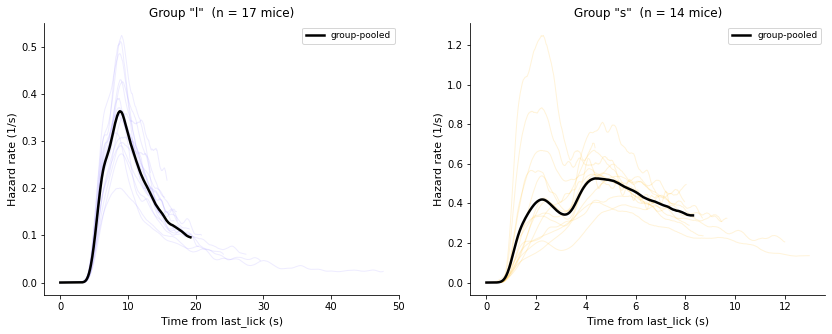

In [65]:
REF_LABEL = 'last_lick'
ref_col   = timing_refs[REF_LABEL]
MIN_TRIALS = 50   # minimum trials per mouse to compute a reliable hazard

# --- Compute per-mouse hazard curves and peak times ---
mouse_hazard = {}   # {(mouse, grp): (t_grid, h)}
mouse_peaks  = {}   # {(mouse, grp): peak_time}

for (mouse, grp), sub in trials.groupby(['mouse', 'group']):
    t = sub[ref_col].dropna().values
    t = t[(t > 0) & np.isfinite(t)]
    if len(t) < MIN_TRIALS:
        continue
    t_grid = np.linspace(0.01, np.quantile(t, 0.95), N_GRID)
    h = kernel_hazard(t, t_grid, bw_method=BW)
    mouse_hazard[(mouse, grp)] = (t_grid, h)
    valid = np.isfinite(h)
    if valid.any():
        mouse_peaks[(mouse, grp)] = t_grid[valid][np.argmax(h[valid])]

n_per_grp = {g: sum(1 for (_, gg) in mouse_hazard if gg == g) for g in groups}
print("Mice included: " + "  ".join(f"group '{g}': {n_per_grp[g]}" for g in groups))

# --- Plot 1: per-mouse overlay + group-pooled ---
fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 5), sharey=False)

for ax, grp in zip(axes, groups):
    color = group_palette[grp]
    for (mouse, g), (tg, h) in mouse_hazard.items():
        if g != grp:
            continue
        valid = np.isfinite(h)
        ax.plot(tg[valid], h[valid], color=color, lw=1, alpha=0.15)
    # Group-pooled in black so it stands apart
    tg_grp, h_grp = hazard_data.get((grp, REF_LABEL), (None, None))
    if tg_grp is not None:
        valid = np.isfinite(h_grp)
        ax.plot(tg_grp[valid], h_grp[valid], color='black', lw=2.5, label='group-pooled')
    ax.set_xlabel(f'Time from {REF_LABEL} (s)', fontsize=11)
    ax.set_ylabel('Hazard rate (1/s)', fontsize=11)
    ax.set_title(f'Group "{grp}"  (n = {n_per_grp[grp]} mice)', fontsize=12)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

Mice included: group 'l': 17  group 's': 14


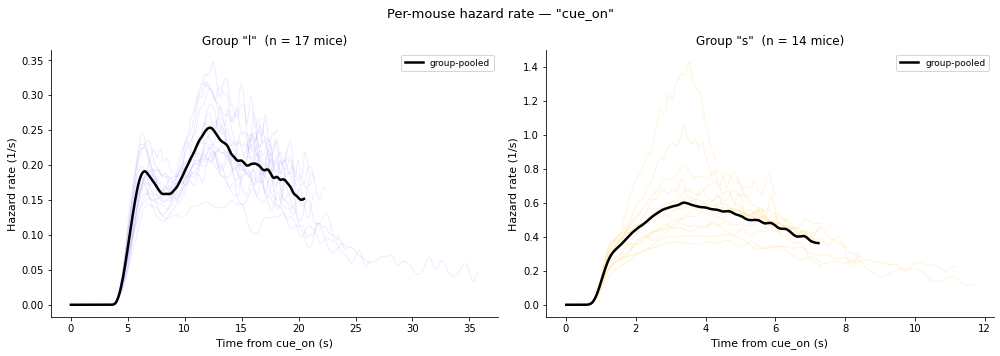

In [66]:
REF_LABEL = 'cue_on'
ref_col   = timing_refs[REF_LABEL]

# --- Compute per-mouse hazard curves and peak times ---
mouse_hazard_co = {}
mouse_peaks_co  = {}

for (mouse, grp), sub in trials.groupby(['mouse', 'group']):
    t = sub[ref_col].dropna().values
    t = t[(t > 0) & np.isfinite(t)]
    if len(t) < MIN_TRIALS:
        continue
    t_grid = np.linspace(0.01, np.quantile(t, 0.95), N_GRID)
    h = kernel_hazard(t, t_grid, bw_method=BW)
    mouse_hazard_co[(mouse, grp)] = (t_grid, h)
    valid = np.isfinite(h)
    if valid.any():
        mouse_peaks_co[(mouse, grp)] = t_grid[valid][np.argmax(h[valid])]

n_per_grp_co = {g: sum(1 for (_, gg) in mouse_hazard_co if gg == g) for g in groups}
print("Mice included: " + "  ".join(f"group '{g}': {n_per_grp_co[g]}" for g in groups))

# --- Plot 1: per-mouse overlay + group-pooled ---
fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 5), sharey=False)

for ax, grp in zip(axes, groups):
    color = group_palette[grp]
    for (mouse, g), (tg, h) in mouse_hazard_co.items():
        if g != grp:
            continue
        valid = np.isfinite(h)
        ax.plot(tg[valid], h[valid], color=color, lw=1, alpha=0.15)
    tg_grp, h_grp = hazard_data.get((grp, REF_LABEL), (None, None))
    if tg_grp is not None:
        valid = np.isfinite(h_grp)
        ax.plot(tg_grp[valid], h_grp[valid], color='black', lw=2.5, label='group-pooled')
    ax.set_xlabel(f'Time from {REF_LABEL} (s)', fontsize=11)
    ax.set_ylabel('Hazard rate (1/s)', fontsize=11)
    ax.set_title(f'Group "{grp}"  (n = {n_per_grp_co[grp]} mice)', fontsize=12)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle(f'Per-mouse hazard rate — "{REF_LABEL}"', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, f'hazard_per_mouse_{REF_LABEL}_overlay.png'), dpi=150)

## Distribution fitting — time_waited_since_last_lick

The shape of this distribution is a model-selection prior for Phase 4:

| Distribution | Mechanism implied | Hazard shape |
|---|---|---|
| **Inverse Gaussian** | Drift-diffusion / noisy accumulator crossing a threshold | Rises then falls |
| **Gamma** | Poisson-like counting of k events at rate λ | Rises monotonically (if k > 1) |
| **Log-normal** | Multiplicative noise on timing | Rises then falls |

We fit all three (MLE, location fixed at 0) and compare via AIC. ΔAIC > 10 is strong evidence against the worse-fitting model. The winner informs which mechanistic model to pursue.

Distribution fit — each group fit to its preferred anchor

  Group 'l'  anchor=time_waited_since_cue_on  (n = 279,988):
 distribution     log_L       AIC    ΔAIC       BIC
Inv. Gaussian -774741.9 1549487.9     0.0 1549508.9
   Log-normal -775489.5 1550983.0  1495.1 1551004.1
        Gamma -790075.0 1580154.1 30666.2 1580175.2

  Group 's'  anchor=time_waited_since_last_lick  (n = 273,538):
 distribution     log_L       AIC    ΔAIC       BIC
Inv. Gaussian -531727.1 1063458.1     0.0 1063479.2
   Log-normal -533687.0 1067378.1  3920.0 1067399.1
        Gamma -544831.3 1089666.6 26208.5 1089687.6



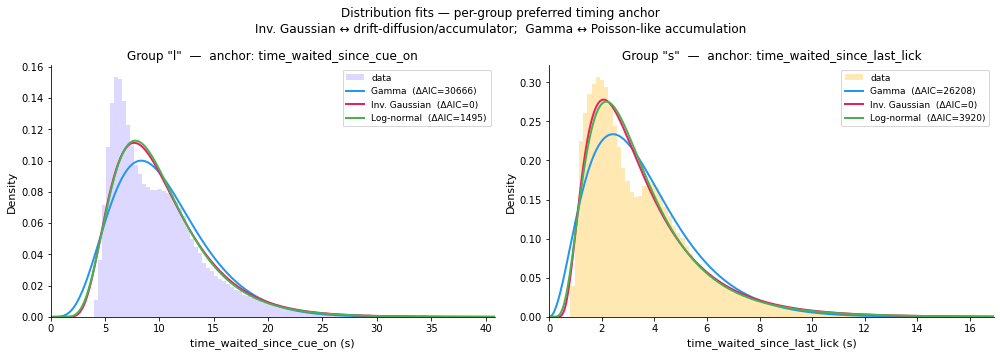

In [25]:
from scipy.stats import gamma as gamma_dist, invgauss, lognorm

# Each group fitted against its preferred timing anchor
group_col = {'l': 'time_waited_since_cue_on', 's': 'time_waited_since_last_lick'}

distributions = {
    'Gamma':         gamma_dist,
    'Inv. Gaussian': invgauss,
    'Log-normal':    lognorm,
}
dist_colors = {
    'Gamma':         '#2196F3',
    'Inv. Gaussian': '#E91E63',
    'Log-normal':    '#4CAF50',
}

# --- Fit and compute AIC / BIC ---
fit_records = []
fitted_params = {}   # {(grp, dist_name): params}

for grp in groups:
    col = group_col[grp]
    t = trials[trials['group'] == grp][col].dropna().values
    t = t[(t > 0) & np.isfinite(t)]
    t_clip = t[t <= np.quantile(t, 0.99)]   # remove extreme tail before fitting
    n = len(t_clip)
    for dist_name, dist in distributions.items():
        params = dist.fit(t_clip, floc=0)    # fix location at 0
        logL = dist.logpdf(t_clip, *params).sum()
        k = 2   # shape + scale; loc fixed
        aic = -2 * logL + 2 * k
        bic = -2 * logL + k * np.log(n)
        fit_records.append(dict(group=grp, distribution=dist_name,
                                col=col, log_L=round(logL, 1),
                                AIC=round(aic, 1), BIC=round(bic, 1), n=n))
        fitted_params[(grp, dist_name)] = params

fit_df = pd.DataFrame(fit_records)

print("Distribution fit — each group fit to its preferred anchor\n")
for grp in groups:
    col = group_col[grp]
    sub = fit_df[fit_df['group'] == grp].sort_values('AIC').reset_index(drop=True)
    sub['ΔAIC'] = (sub['AIC'] - sub['AIC'].min()).round(1)
    print(f"  Group '{grp}'  anchor={col}  (n = {sub['n'].iloc[0]:,}):")
    print(sub[['distribution', 'log_L', 'AIC', 'ΔAIC', 'BIC']].to_string(index=False))
    print()

# --- Plot: histogram + fitted PDFs ---
fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 5))

for ax, grp in zip(axes, groups):
    col = group_col[grp]
    t = trials[trials['group'] == grp][col].dropna().values
    t = t[(t > 0) & np.isfinite(t)]
    x_cap = np.quantile(t, 0.99)
    ax.hist(t[t <= x_cap], bins=100, density=True,
            color=group_palette[grp], alpha=0.3, label='data')
    t_grid_fit = np.linspace(0.001, x_cap, 500)
    for dist_name, dist in distributions.items():
        params = fitted_params[(grp, dist_name)]
        sub_aic = fit_df[(fit_df['group'] == grp) & (fit_df['distribution'] == dist_name)]
        delta = (sub_aic['AIC'].values[0]
                 - fit_df[fit_df['group'] == grp]['AIC'].min())
        ax.plot(t_grid_fit, dist.pdf(t_grid_fit, *params),
                color=dist_colors[dist_name], lw=2,
                label=f"{dist_name}  (ΔAIC={delta:.0f})")
    ax.set_xlabel(col + ' (s)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Group "{grp}"  —  anchor: {col}', fontsize=12)
    ax.set_xlim(0, x_cap)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Distribution fits — per-group preferred timing anchor\n'
             'Inv. Gaussian ↔ drift-diffusion/accumulator;  Gamma ↔ Poisson-like accumulation',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'dist_fit_by_preferred_anchor.png'), dpi=150)
plt.show()

# Spliting trial types

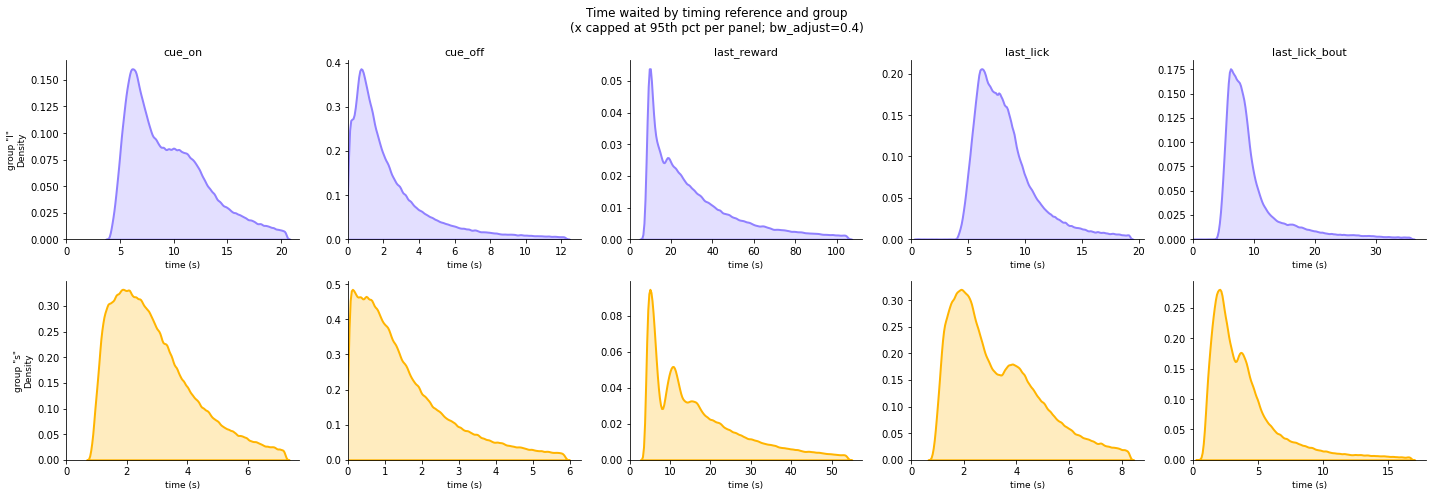

In [26]:
# Distribution of time waited — 2 rows × 5 cols (top = long, bottom = short)
# Each panel uses that group's own x range; bw_adjust=0.4 for less smoothing

n_refs = len(timing_refs)
fig, axes = plt.subplots(2, n_refs, figsize=(4 * n_refs, 7))

for row, grp in enumerate(groups):   # groups = ['l', 's'] → top = long, bottom = short
    grp_trials = trials[trials['group'] == grp]
    color = group_palette[grp]

    for col, (label, col_name) in enumerate(timing_refs.items()):
        ax = axes[row, col]

        if col_name not in trials.columns:
            ax.set_visible(False)
            continue

        t = grp_trials[col_name].dropna().values
        cap = np.quantile(t, 0.95)
        t = t[t <= cap]

        if len(t) >= 2:
            sns.kdeplot(t, ax=ax, color=color, lw=2,
                        fill=True, alpha=0.25, bw_adjust=0.4)

        ax.set_xlim(left=0)
        ax.set_xlabel('time (s)', fontsize=9)
        ax.set_ylabel('Density' if col == 0 else '', fontsize=9)
        if row == 0:
            ax.set_title(label, fontsize=11)
        # Group label on leftmost panel
        if col == 0:
            ax.set_ylabel(f'group "{grp}"\nDensity', fontsize=9)
        sns.despine(ax=ax)

fig.suptitle('Time waited by timing reference and group\n'
             '(x capped at 95th pct per panel; bw_adjust=0.4)',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [27]:
n_under = (trials['time_waited_since_last_lick_bout'] < 0.5).sum()
n_total = trials['time_waited_since_last_lick_bout'].notna().sum()
print(f"Trials with time_waited_since_last_lick_bout < 0.5s: {n_under:,} / {n_total:,} ({n_under/n_total:.2%})")

# also check if they correlate with bg licks
if 'num_bg_licks' in trials.columns:
    under = trials[trials['time_waited_since_last_lick_bout'] < 0.5]
    print(f"\nOf those, trials with num_bg_licks > 0: {(under['num_bg_licks'] > 0).sum():,} ({(under['num_bg_licks'] > 0).mean():.2%})")
    print(f"vs overall rate of num_bg_licks > 0:    {(trials['num_bg_licks'] > 0).mean():.2%}")

Trials with time_waited_since_last_lick_bout < 0.5s: 0 / 558,358 (0.00%)

Of those, trials with num_bg_licks > 0: 0 (nan%)
vs overall rate of num_bg_licks > 0:    47.88%


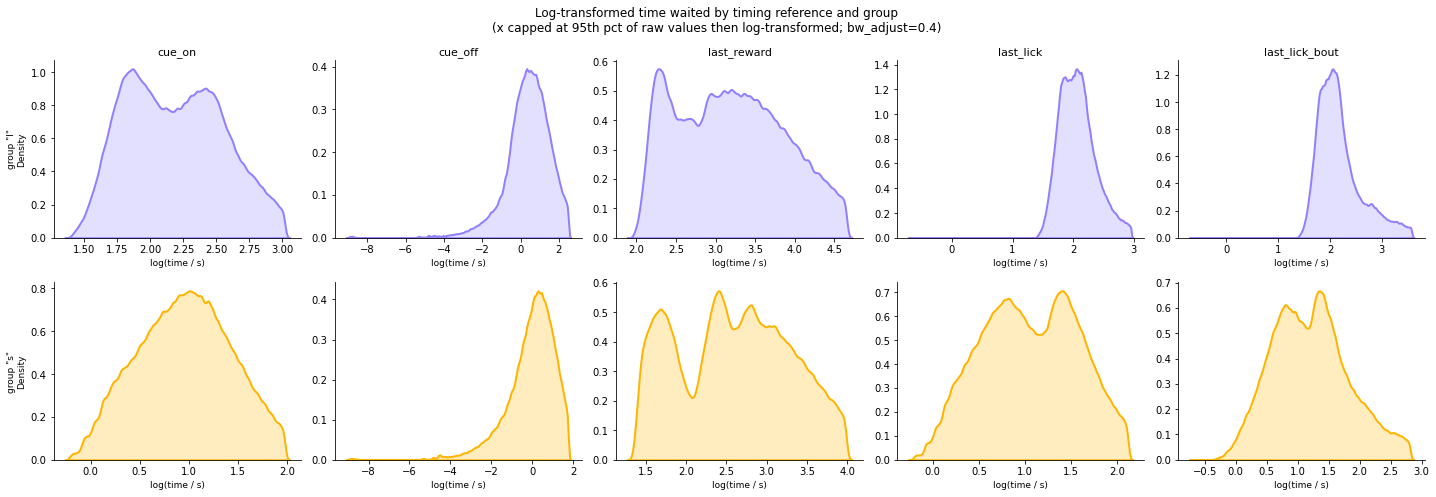

In [28]:
# Same 2×5 grid but with log-transformed time values
# KDE is computed on log(t) so the shape reflects the log-space distribution

n_refs = len(timing_refs)
fig, axes = plt.subplots(2, n_refs, figsize=(4 * n_refs, 7))

for row, grp in enumerate(groups):
    grp_trials = trials[trials['group'] == grp]
    color = group_palette[grp]

    for col, (label, col_name) in enumerate(timing_refs.items()):
        ax = axes[row, col]

        if col_name not in trials.columns:
            ax.set_visible(False)
            continue

        t = grp_trials[col_name].dropna().values
        t = t[t > 0]                          # log requires positive values
        cap = np.quantile(t, 0.95)
        t = t[t <= cap]
        log_t = np.log(t)

        if len(log_t) >= 2:
            sns.kdeplot(log_t, ax=ax, color=color, lw=2,
                        fill=True, alpha=0.25, bw_adjust=0.4)

        ax.set_xlabel('log(time / s)', fontsize=9)
        if row == 0:
            ax.set_title(label, fontsize=11)
        if col == 0:
            ax.set_ylabel(f'group "{grp}"\nDensity', fontsize=9)
        else:
            ax.set_ylabel('')
        sns.despine(ax=ax)

fig.suptitle('Log-transformed time waited by timing reference and group\n'
             '(x capped at 95th pct of raw values then log-transformed; bw_adjust=0.4)',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_distributions_log.png'), dpi=150, bbox_inches='tight')
plt.show()

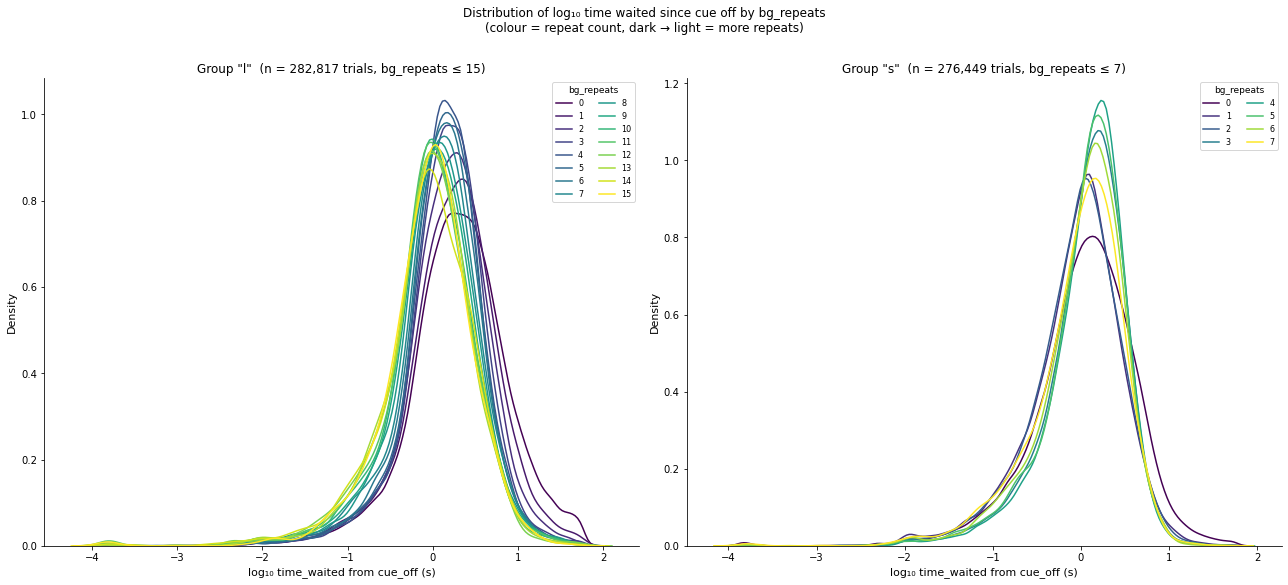

In [29]:
BG_REPEAT_CUTOFF = {'s': 7, 'l': 15}

fig, axes = plt.subplots(1, len(groups), figsize=(9 * len(groups), 8), sharey=False)

for ax, grp in zip(axes, groups):
    cutoff = BG_REPEAT_CUTOFF[grp]
    g = (trials[trials['group'] == grp]
         .dropna(subset=['bg_repeats', 'time_waited'])
         .pipe(lambda df: df[df['bg_repeats'] <= cutoff]))
    repeat_vals = sorted(g['bg_repeats'].unique())
    cmap = plt.get_cmap('viridis', len(repeat_vals))

    for i, rep in enumerate(repeat_vals):
        t = g.loc[g['bg_repeats'] == rep, 'time_waited'].values
        t = t[(t > 0) & np.isfinite(t)]
        log_t = np.log10(t)
        if len(log_t) < 2 or log_t.std() == 0:
            continue
        sns.kdeplot(log_t, ax=ax, color=cmap(i), lw=1.5, label=str(int(rep)))

    rho = g['bg_repeats'].corr(g['time_waited'], method='spearman')

    ax.set_xlabel('log₁₀ time_waited from cue_off (s)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Group "{grp}"  (n = {len(g):,} trials, bg_repeats ≤ {cutoff})', fontsize=12)
    ax.legend(title='bg_repeats', fontsize=8, title_fontsize=9,
              loc='upper right', ncol=2)
    sns.despine(ax=ax)

fig.suptitle('Distribution of log₁₀ time waited since cue off by bg_repeats\n'
             '(colour = repeat count, dark → light = more repeats)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_by_bg_repeats_kde.png'), dpi=150, bbox_inches='tight')
plt.show()

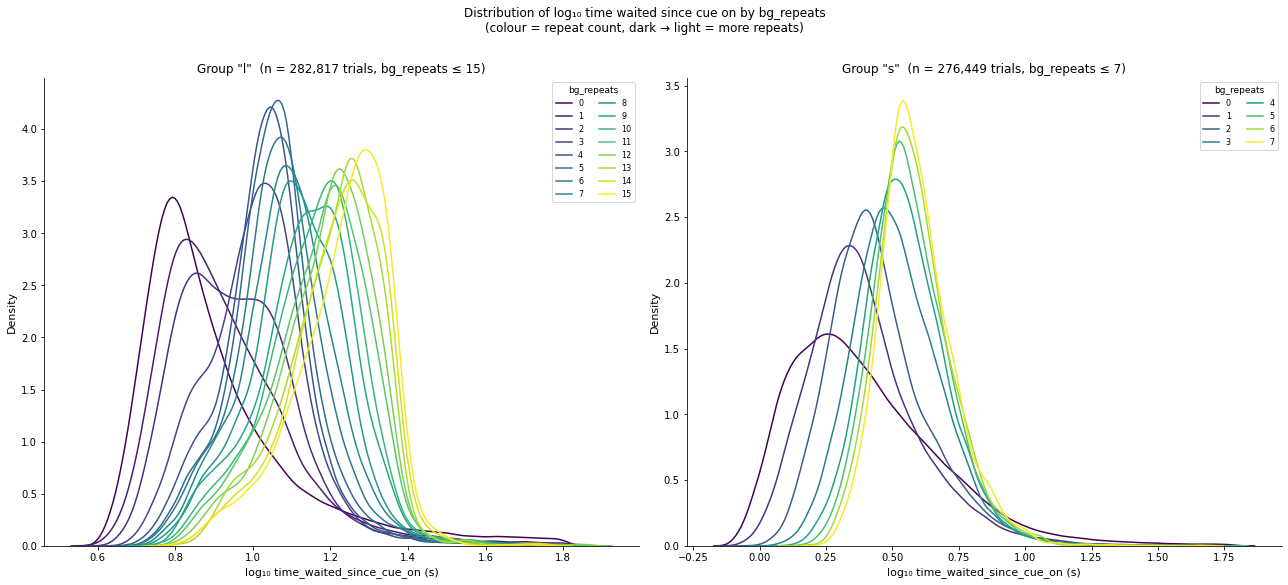

In [30]:
BG_REPEAT_CUTOFF = {'s': 7, 'l': 15}

fig, axes = plt.subplots(1, len(groups), figsize=(9 * len(groups), 8), sharey=False)

for ax, grp in zip(axes, groups):
    cutoff = BG_REPEAT_CUTOFF[grp]
    g = (trials[trials['group'] == grp]
         .dropna(subset=['bg_repeats', 'time_waited_since_cue_on'])
         .pipe(lambda df: df[df['bg_repeats'] <= cutoff]))
    repeat_vals = sorted(g['bg_repeats'].unique())
    cmap = plt.get_cmap('viridis', len(repeat_vals))

    for i, rep in enumerate(repeat_vals):
        t = g.loc[g['bg_repeats'] == rep, 'time_waited_since_cue_on'].values
        t = t[(t > 0) & np.isfinite(t)]
        log_t = np.log10(t)
        if len(log_t) < 2 or log_t.std() == 0:
            continue
        sns.kdeplot(log_t, ax=ax, color=cmap(i), lw=1.5, label=str(int(rep)))

    rho = g['bg_repeats'].corr(g['time_waited_since_cue_on'], method='spearman')

    ax.set_xlabel('log₁₀ time_waited_since_cue_on (s)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Group "{grp}"  (n = {len(g):,} trials, bg_repeats ≤ {cutoff})', fontsize=12)
    ax.legend(title='bg_repeats', fontsize=8, title_fontsize=9,
              loc='upper right', ncol=2)
    sns.despine(ax=ax)

fig.suptitle('Distribution of log₁₀ time waited since cue on by bg_repeats\n'
             '(colour = repeat count, dark → light = more repeats)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_since_cue_on_by_bg_repeats_kde.png'), dpi=150, bbox_inches='tight')
plt.show()

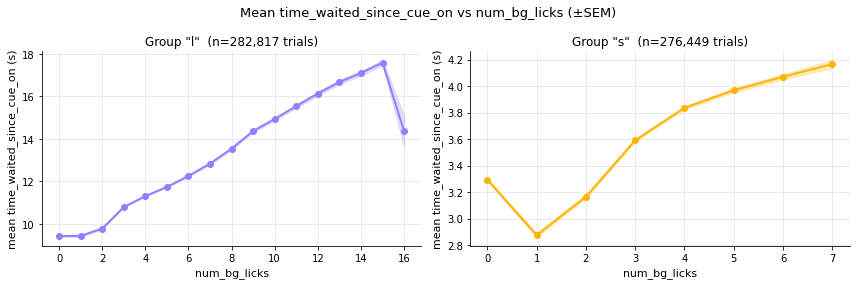

In [31]:
fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4), sharey=False)

for ax, grp in zip(axes, groups):
    g = trials[trials['group'] == grp].dropna(subset=['num_bg_licks', 'time_waited_since_cue_on'])
    stats = (g.groupby('num_bg_licks')['time_waited_since_cue_on']
               .agg(mean='mean', sem=lambda x: x.sem(), n='count')
               .reset_index())

    ax.plot(stats['num_bg_licks'], stats['mean'], marker='o', color=group_palette[grp], linewidth=2)
    ax.fill_between(stats['num_bg_licks'],
                    stats['mean'] - stats['sem'],
                    stats['mean'] + stats['sem'],
                    alpha=0.25, color=group_palette[grp])
    ax.set_xlabel('num_bg_licks', fontsize=11)
    ax.set_ylabel('mean time_waited_since_cue_on (s)', fontsize=11)
    ax.set_title(f'Group "{grp}"  (n={len(g):,} trials)', fontsize=12)
    ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle('Mean time_waited_since_cue_on vs num_bg_licks (±SEM)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_since_cue_on_vs_bg_licks.png'), dpi=150, bbox_inches='tight')
plt.show()

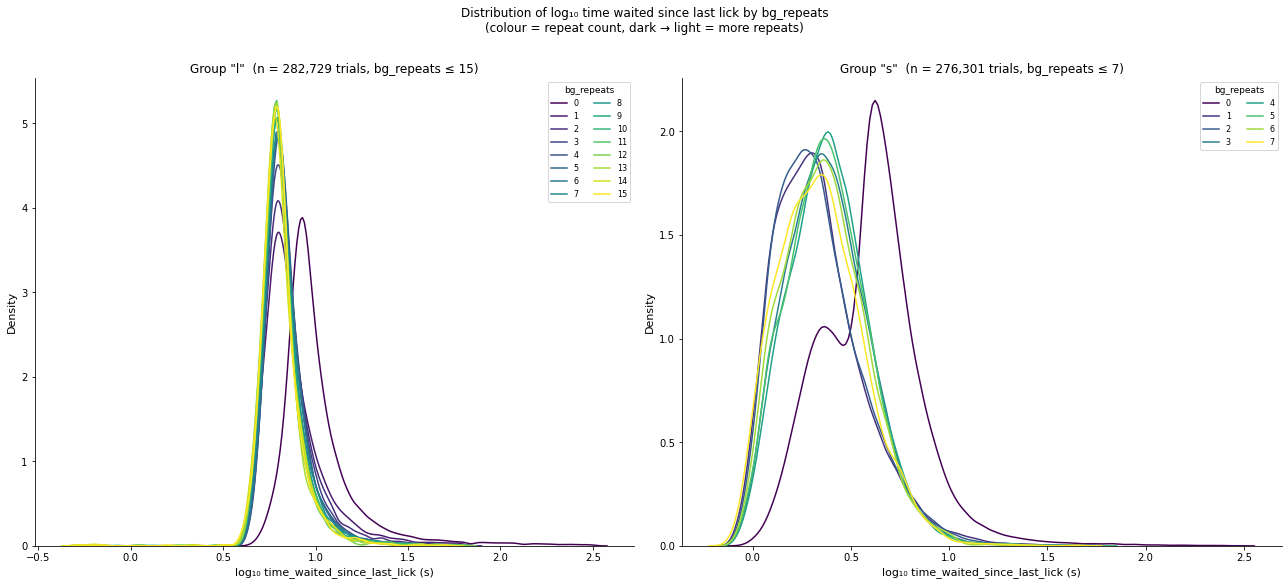

In [32]:
BG_REPEAT_CUTOFF = {'s': 7, 'l': 15}

fig, axes = plt.subplots(1, len(groups), figsize=(9 * len(groups), 8), sharey=False)

for ax, grp in zip(axes, groups):
    cutoff = BG_REPEAT_CUTOFF[grp]
    g = (trials[trials['group'] == grp]
         .dropna(subset=['bg_repeats', 'time_waited_since_last_lick'])
         .pipe(lambda df: df[df['bg_repeats'] <= cutoff]))
    repeat_vals = sorted(g['bg_repeats'].unique())
    cmap = plt.get_cmap('viridis', len(repeat_vals))

    for i, rep in enumerate(repeat_vals):
        t = g.loc[g['bg_repeats'] == rep, 'time_waited_since_last_lick'].values
        t = t[(t > 0) & np.isfinite(t)]
        log_t = np.log10(t)
        if len(log_t) < 2 or log_t.std() == 0:
            continue
        sns.kdeplot(log_t, ax=ax, color=cmap(i), lw=1.5, label=str(int(rep)))

    rho = g['bg_repeats'].corr(g['time_waited_since_last_lick'], method='spearman')

    ax.set_xlabel('log₁₀ time_waited_since_last_lick (s)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Group "{grp}"  (n = {len(g):,} trials, bg_repeats ≤ {cutoff})', fontsize=12)
    ax.legend(title='bg_repeats', fontsize=8, title_fontsize=9,
              loc='upper right', ncol=2)
    sns.despine(ax=ax)

fig.suptitle('Distribution of log₁₀ time waited since last lick by bg_repeats\n'
             '(colour = repeat count, dark → light = more repeats)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_since_last_lick_by_bg_repeats_kde.png'), dpi=150, bbox_inches='tight')
plt.show()

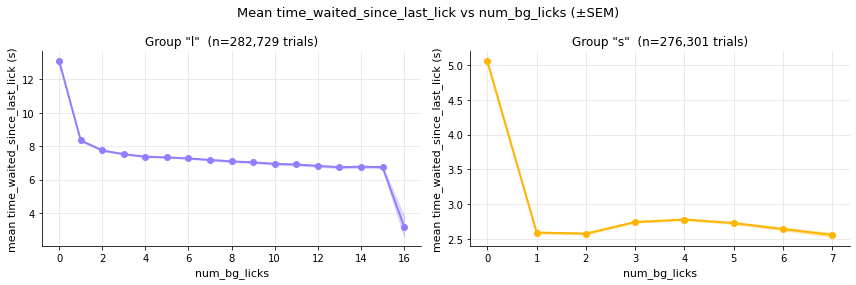

In [33]:
fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4), sharey=False)

for ax, grp in zip(axes, groups):
    g = trials[trials['group'] == grp].dropna(subset=['num_bg_licks', 'time_waited_since_last_lick'])
    stats = (g.groupby('num_bg_licks')['time_waited_since_last_lick']
               .agg(mean='mean', sem=lambda x: x.sem(), n='count')
               .reset_index())

    ax.plot(stats['num_bg_licks'], stats['mean'], marker='o', color=group_palette[grp], linewidth=2)
    ax.fill_between(stats['num_bg_licks'],
                    stats['mean'] - stats['sem'],
                    stats['mean'] + stats['sem'],
                    alpha=0.25, color=group_palette[grp])
    ax.set_xlabel('num_bg_licks', fontsize=11)
    ax.set_ylabel('mean time_waited_since_last_lick (s)', fontsize=11)
    ax.set_title(f'Group "{grp}"  (n={len(g):,} trials)', fontsize=12)
    ax.grid(True, alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle('Mean time_waited_since_last_lick vs num_bg_licks (±SEM)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_since_last_lick_vs_bg_licks.png'), dpi=150, bbox_inches='tight')
plt.show()

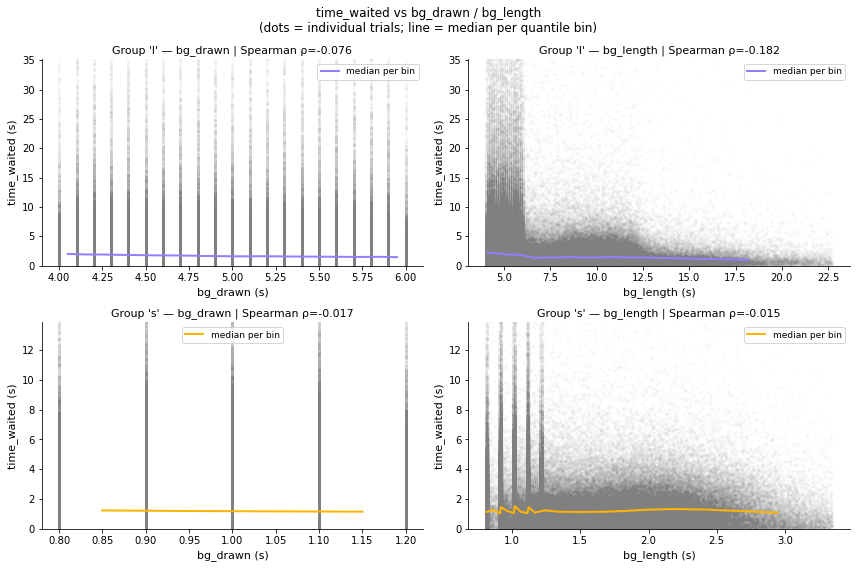

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, grp in enumerate(['l', 's']):
    g = trials[trials['group'] == grp].dropna(
        subset=['time_waited', 'bg_drawn', 'bg_length']).copy()

    for col, (x_col, x_label) in enumerate([
        ('bg_drawn',   'bg_drawn (s)'),
        ('bg_length',  'bg_length (s)')
    ]):
        ax = axes[row, col]

        g['x_bin'] = pd.qcut(g[x_col], q=20, duplicates='drop')
        binned = g.groupby('x_bin', observed=True)['time_waited'].median()
        bin_centers = [iv.mid for iv in binned.index]

        ax.scatter(g[x_col], g['time_waited'],
                   alpha=0.02, s=5, color='gray')
        ax.plot(bin_centers, binned.values,
                color=group_palette[grp], lw=2, label='median per bin')

        rho, _ = spearmanr(g[x_col], g['time_waited'])
        ax.set_xlabel(x_label, fontsize=11)
        ax.set_ylabel('time_waited (s)', fontsize=11)
        ax.set_title(f"Group '{grp}' — {x_col} | Spearman ρ={rho:.3f}", fontsize=11)
        ax.set_ylim(0, g['time_waited'].quantile(0.99))
        ax.legend(fontsize=9)
        sns.despine(ax=ax)

fig.suptitle('time_waited vs bg_drawn / bg_length\n(dots = individual trials; line = median per quantile bin)',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_vs_bg_drawn_length.png'), dpi=150, bbox_inches='tight')
plt.show()

In [35]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm


def classify_trials_gmm_log(values, n_components=2, random_state=0):
    """
    Fit a 2-component GMM in log-space and return classification results.

    Parameters
    ----------
    values : array-like of raw (non-log) wait times (must be positive)

    Returns
    -------
    dict with keys:
        labels        : hard assignment (0 or 1)
        p_late        : posterior prob of being in the higher-mean (log-space) component
        means_log     : component means in log-space
        means_raw     : component means back-transformed via exp
        threshold_log : crossover point in log-space (where posteriors are equal)
        threshold_raw : threshold back-transformed to seconds
        gmm           : fitted GaussianMixture object
        log_vals      : log-transformed input values
    """
    log_vals = np.log(values)
    X = log_vals.reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components,
                          random_state=random_state,
                          n_init=10)
    gmm.fit(X)

    probs = gmm.predict_proba(X)
    labels = gmm.predict(X)
    means_log = gmm.means_.flatten()

    early_component = np.argmin(means_log)
    late_component  = np.argmax(means_log)

    # Find crossover threshold in log-space
    x_grid = np.linspace(log_vals.min(), log_vals.max(), 10000).reshape(-1, 1)
    p_grid = gmm.predict_proba(x_grid)
    crossover_idx = np.argmin(np.abs(
        p_grid[:, early_component] - p_grid[:, late_component]
    ))
    threshold_log = x_grid[crossover_idx, 0]

    return {
        'labels':         labels,
        'p_late':         probs[:, late_component],
        'means_log':      means_log,
        'means_raw':      np.exp(means_log),
        'threshold_log':  threshold_log,
        'threshold_raw':  np.exp(threshold_log),
        'gmm':            gmm,
        'log_vals':       log_vals,
    }

In [36]:
# Group 'l': classify on log(time_waited_since_cue_on)
l_mask = (trials['group'] == 'l') & trials['time_waited_since_cue_on'].notna()
l_vals_raw = trials.loc[l_mask, 'time_waited_since_cue_on'].values
l_result = classify_trials_gmm_log(l_vals_raw)

# Group 's': classify on log(time_waited_since_last_lick)
s_mask = (trials['group'] == 's') & trials['time_waited_since_last_lick'].notna()
s_vals_raw = trials.loc[s_mask, 'time_waited_since_last_lick'].values
s_result = classify_trials_gmm_log(s_vals_raw)

# Write results back to trials
trials.loc[l_mask, 'p_true_timing'] = l_result['p_late']
trials.loc[l_mask, 'trial_type']    = np.where(l_result['p_late'] > 0.5, 'true_timing', 'aim_for_end')

trials.loc[s_mask, 'p_true_timing'] = s_result['p_late']
trials.loc[s_mask, 'trial_type']    = np.where(s_result['p_late'] > 0.5, 'true_timing', 'aim_for_end')

# Summary
for grp, result, col in [('l', l_result, 'time_waited_since_cue_on'),
                           ('s', s_result, 'time_waited_since_last_lick')]:
    print(f"\nGroup '{grp}' ({col})")
    print(f"  Component means (raw): {np.round(result['means_raw'], 2)}s")
    print(f"  Threshold (log): {result['threshold_log']:.3f}  →  raw: {result['threshold_raw']:.2f}s")
    n_true = (trials.loc[trials['group'] == grp, 'trial_type'] == 'true_timing').sum()
    n_aim  = (trials.loc[trials['group'] == grp, 'trial_type'] == 'aim_for_end').sum()
    print(f"  true_timing: {n_true}  |  aim_for_end: {n_aim}")


Group 'l' (time_waited_since_cue_on)
  Component means (raw): [ 7.1  12.31]s
  Threshold (log): 2.249  →  raw: 9.48s
  true_timing: 131598  |  aim_for_end: 151219

Group 's' (time_waited_since_last_lick)
  Component means (raw): [4.24 2.07]s
  Threshold (log): 1.072  →  raw: 2.92s
  true_timing: 140456  |  aim_for_end: 135845


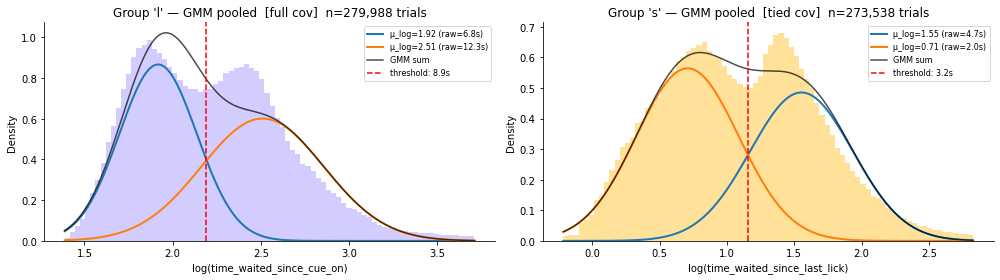

In [37]:
# Verification: pooled GMM fit using the same per-mouse method
# (clip at 99th pct, per-group covariance type, crossover threshold)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_configs = [
    ('l', 'time_waited_since_cue_on',    '#9080ff'),
    ('s', 'time_waited_since_last_lick', '#ffb400'),
]

for ax, (grp, col, color) in zip(axes, plot_configs):
    vals = trials[(trials['group'] == grp) & trials[col].notna()][col].values
    vals = vals[vals > 0]

    log_vals = np.log(vals)
    cap = np.quantile(log_vals, 0.99)
    log_clipped = log_vals[log_vals <= cap]
    X = log_clipped.reshape(-1, 1)

    cov_type = 'tied' if grp == 's' else 'full'
    gmm = GaussianMixture(n_components=2, covariance_type=cov_type,
                          n_init=10, random_state=0).fit(X)

    w = gmm.weights_
    m = gmm.means_.flatten()
    if cov_type == 'tied':
        stds = [float(np.sqrt(gmm.covariances_.flatten()[0]))] * 2
    else:
        stds = [float(np.sqrt(c.flatten()[0])) for c in gmm.covariances_]

    ax.hist(log_clipped, bins=80, density=True, alpha=0.4, color=color)

    x_grid = np.linspace(log_clipped.min(), cap, 1000)
    comp_densities = []
    for wi, mi, si in zip(w, m, stds):
        comp = wi * norm.pdf(x_grid, mi, si)
        comp_densities.append(comp)
        ax.plot(x_grid, comp, lw=2, label=f'μ_log={mi:.2f} (raw={np.exp(mi):.1f}s)')
    ax.plot(x_grid, comp_densities[0] + comp_densities[1], lw=1.5,
            color='black', alpha=0.7, label='GMM sum')

    # Crossover threshold
    between = (x_grid >= min(m)) & (x_grid <= max(m))
    diff = comp_densities[0][between] - comp_densities[1][between]
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    threshold_log = x_grid[between][sign_changes[0]] if len(sign_changes) > 0 else float(np.mean(m))
    threshold_raw = np.exp(threshold_log)

    ax.axvline(threshold_log, color='red', linestyle='--',
               label=f'threshold: {threshold_raw:.1f}s')
    ax.set_xlabel(f'log({col})')
    ax.set_ylabel('Density')
    ax.set_title(f"Group '{grp}' — GMM pooled  [{cov_type} cov]  n={len(log_clipped):,} trials")
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'gmm_classification_log_space.png'), dpi=150)
plt.show()


In [38]:
group_col_map = {
    'l': 'time_waited_since_cue_on',
    's': 'time_waited_since_last_lick',
}

DBIC_THRESHOLD = 10
SEP_THRESHOLD  = 1.0

results = []

for grp, col in group_col_map.items():
    g = trials[trials['group'] == grp]

    # 's' has similar spreads per mode → tied is appropriate
    # 'l' has genuinely different spreads → full prevents compromise fits
    cov_type = 'tied' if grp == 's' else 'full'

    for mouse, mouse_data in g.groupby('mouse'):
        vals = mouse_data[col].dropna().values
        vals = vals[vals > 0]

        if len(vals) < 50:
            continue

        log_vals = np.log(vals)
        cap = np.quantile(log_vals, 0.99)
        log_clipped = log_vals[log_vals <= cap]
        X = log_clipped.reshape(-1, 1)

        gmm1 = GaussianMixture(n_components=1, covariance_type=cov_type,
                               n_init=5,  random_state=0).fit(X)
        gmm2 = GaussianMixture(n_components=2, covariance_type=cov_type,
                               n_init=10, random_state=0).fit(X)

        delta_bic = gmm1.bic(X) - gmm2.bic(X)

        means = gmm2.means_.flatten()
        if cov_type == 'tied':
            shared_std = float(np.sqrt(gmm2.covariances_.flatten()[0]))
            separation = float(np.abs(np.diff(means)[0]) / shared_std)
        else:  # full: per-component variances
            stds = np.sqrt(gmm2.covariances_.flatten())
            separation = float(np.abs(np.diff(means)[0]) / np.mean(stds))

        results.append({
            'mouse':      mouse,
            'group':      grp,
            'col':        col,
            'n_trials':   len(log_clipped),
            'delta_bic':  round(delta_bic, 1),
            'separation': round(separation, 3),
            'bimodal':    (delta_bic > DBIC_THRESHOLD) and (separation >= SEP_THRESHOLD),
            'gmm2':       gmm2,
            'cap':        cap,
        })

bdf = pd.DataFrame(results).sort_values(['group', 'delta_bic'], ascending=[True, False])

print(f"GMM BIC comparison per mouse  (ΔBIC threshold={DBIC_THRESHOLD}, separation threshold={SEP_THRESHOLD})\n")
print(f"{'mouse':12s} {'group':6s} {'cov':6s} {'n_trials':>10} {'ΔBIC':>10} {'sep':>8} {'bimodal?':>10}")
print("-" * 65)
for _, row in bdf.iterrows():
    flag = '✓' if row['bimodal'] else ' '
    cov = row['gmm2'].covariance_type
    print(f"{row['mouse']:12s} {row['group']:6s} {cov:6s} {row['n_trials']:>10,} "
          f"{row['delta_bic']:>10.1f} {row['separation']:>8.3f} {flag:>10}")

print(f"\nSummary:")
for grp in ['l', 's']:
    sub = bdf[bdf['group'] == grp]
    n_bi = sub['bimodal'].sum()
    cov = 'full' if grp == 'l' else 'tied'
    print(f"  Group '{grp}' ({cov}): {n_bi}/{len(sub)} mice bimodal")


GMM BIC comparison per mouse  (ΔBIC threshold=10, separation threshold=1.0)

mouse        group  cov      n_trials       ΔBIC      sep   bimodal?
-----------------------------------------------------------------
RZ056        l      full       28,216     3171.6    2.683          ✓
RZ053        l      full       30,768     3027.6    2.433          ✓
RZ037        l      full       22,400     2568.5    2.513          ✓
RZ052        l      full       24,118     2334.6    2.536          ✓
RZ054        l      full       24,867     1942.5    1.752          ✓
RZ039        l      full       17,727     1410.2    1.900          ✓
RZ082        l      full        9,824     1306.2    2.468          ✓
RZ059        l      full       15,609     1265.2    1.970          ✓
RZ055        l      full       16,438     1060.5    1.748          ✓
RZ065        l      full       13,393     1024.7    2.481          ✓
RZ067        l      full       12,594     1021.0    2.219          ✓
RZ058        l      full     

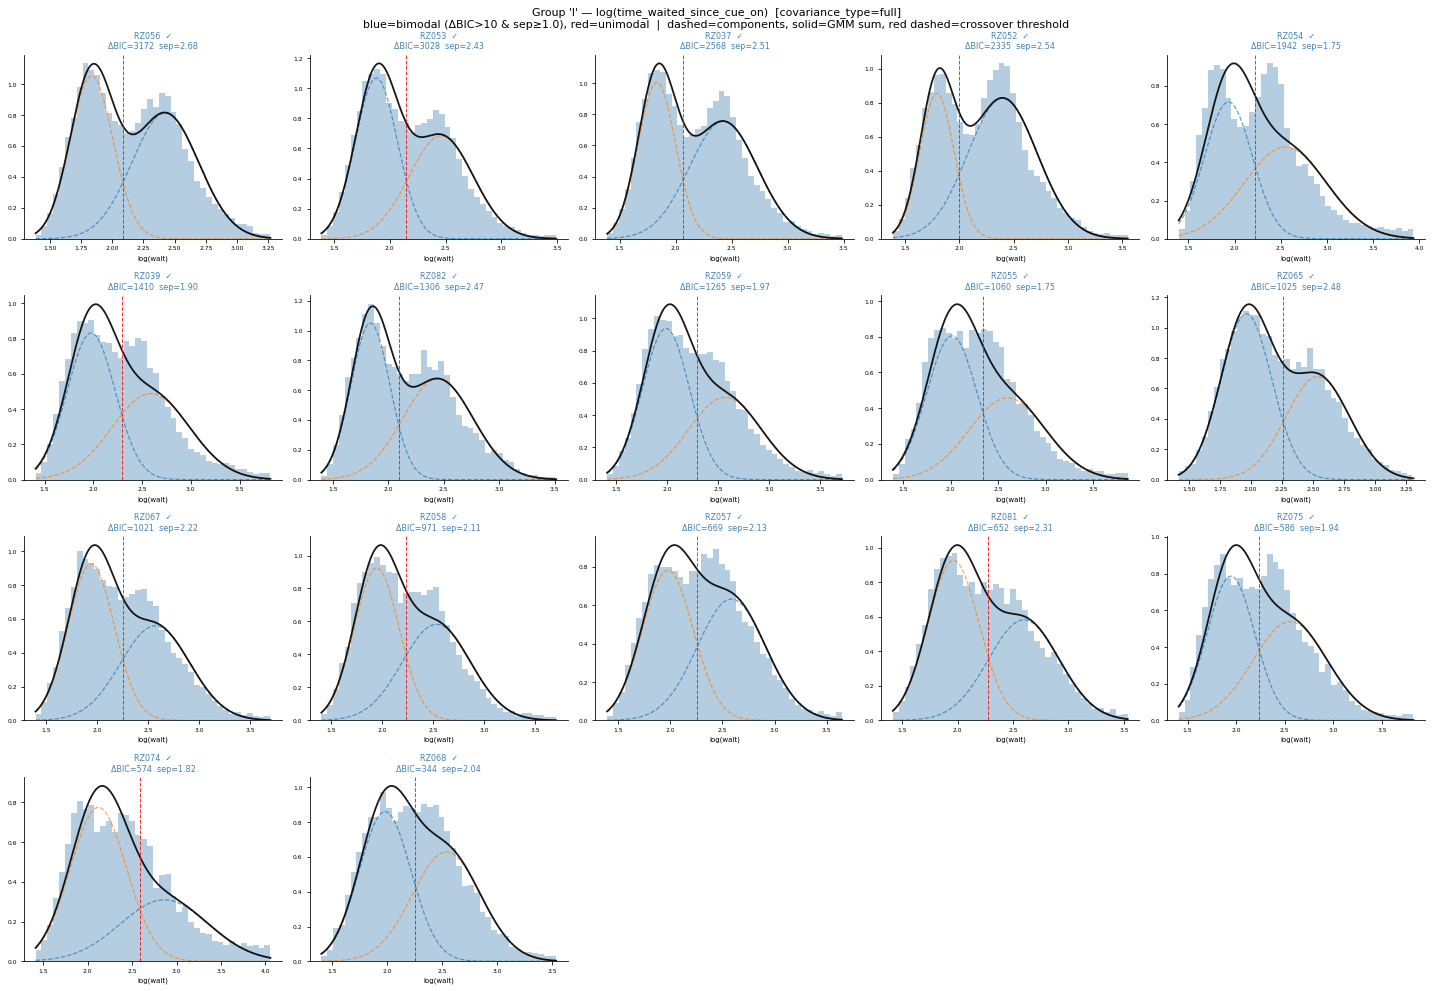

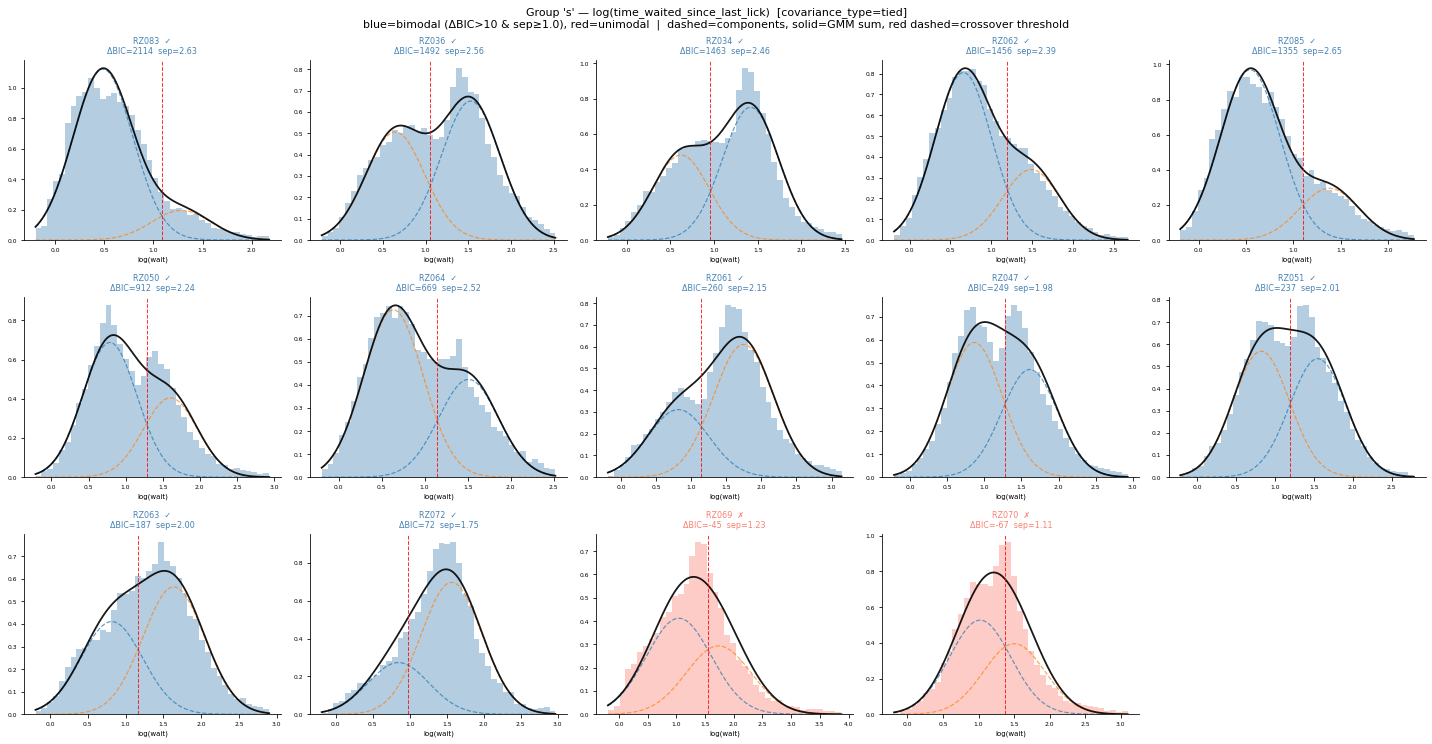

In [39]:

n_cols = 5

for grp, col in group_col_map.items():
    mice = bdf[bdf['group'] == grp].sort_values('delta_bic', ascending=False)
    n_mice = len(mice)
    n_rows = int(np.ceil(n_mice / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten()

    for i, (_, row) in enumerate(mice.iterrows()):
        ax = axes[i]
        vals = trials[
            (trials['group'] == grp) &
            (trials['mouse'] == row['mouse'])
        ][col].dropna().values
        vals = vals[vals > 0]

        log_vals = np.log(vals)
        cap = row['cap']
        plot_vals = log_vals[log_vals <= cap]

        ax.hist(plot_vals, bins=40, density=True,
                color='steelblue' if row['bimodal'] else 'salmon', alpha=0.4)

        gmm2   = row['gmm2']
        x_grid = np.linspace(plot_vals.min(), cap, 500)
        w = gmm2.weights_
        m = gmm2.means_.flatten()

        # Per-component stds (handles both tied and full covariance)
        if gmm2.covariance_type == 'tied':
            stds = [float(np.sqrt(gmm2.covariances_.flatten()[0]))] * len(m)
        else:
            stds = [float(np.sqrt(c.flatten()[0])) for c in gmm2.covariances_]

        # Plot components and total
        total = np.zeros(len(x_grid))
        comp_densities = []
        for wi, mi, si in zip(w, m, stds):
            component = wi * norm.pdf(x_grid, mi, si)
            comp_densities.append(component)
            ax.plot(x_grid, component, lw=1.2, linestyle='--', alpha=0.7)
            total += component
        ax.plot(x_grid, total, lw=1.8, color='black', alpha=0.9)

        # Threshold: where the two weighted component densities cross between the means
        between = (x_grid >= min(m)) & (x_grid <= max(m))
        diff = comp_densities[0][between] - comp_densities[1][between]
        sign_changes = np.where(np.diff(np.sign(diff)))[0]

        if len(sign_changes) > 0:
            threshold = x_grid[between][sign_changes[0]]
        else:
            threshold = float(np.mean(m))  # fallback: midpoint of means

        ax.axvline(threshold, color='red', lw=1, linestyle='--', alpha=0.8)

        ax.set_title(
            f"{row['mouse']}  {'✓' if row['bimodal'] else '✗'}\n"
            f"ΔBIC={row['delta_bic']:.0f}  sep={row['separation']:.2f}",
            fontsize=8,
            color='steelblue' if row['bimodal'] else 'salmon'
        )
        ax.set_xlabel('log(wait)', fontsize=7)
        ax.tick_params(labelsize=6)
        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    cov_label = 'tied' if grp == 's' else 'full'
    fig.suptitle(
        f"Group '{grp}' — log({col})  [covariance_type={cov_label}]\n"
        f"blue=bimodal (ΔBIC>{DBIC_THRESHOLD} & sep≥{SEP_THRESHOLD}), red=unimodal  |  "
        f"dashed=components, solid=GMM sum, red dashed=crossover threshold",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(os.path.join(figure_folder, f'bimodality_per_mouse_{grp}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


In [40]:
trials['trial_type']    = np.nan  # start with all unknown
trials['p_true_timing'] = np.nan

# Only assign labels for mice that pass bimodality check
bimodal_mice = bdf[bdf['bimodal']]['mouse'].tolist()

# Fit per-mouse GMM and classify — only for bimodal mice
for _, row in bdf[bdf['bimodal']].iterrows():
    grp   = row['group']
    col   = row['col']
    mouse = row['mouse']

    mask = (trials['group'] == grp) & (trials['mouse'] == mouse) & trials[col].notna()
    if mask.sum() < 50:
        continue

    result = classify_trials_gmm_log(trials.loc[mask, col].values)
    trials.loc[mask, 'p_true_timing'] = result['p_late']
    trials.loc[mask, 'trial_type']    = np.where(
        result['p_late'] > 0.5, 'true_timing', 'aim_for_end'
    )

# For remaining mice, trial_type stays NaN — don't exclude, handle separately in analysis
n_classified = trials['trial_type'].notna().sum()
n_nan        = trials['trial_type'].isna().sum()
print(f"Bimodal mice ({len(bimodal_mice)}): {bimodal_mice}")
print(f"\nClassified:  {n_classified:,} trials")
print(f"Unclassified (NaN): {n_nan:,} trials  "
      f"({n_nan / len(trials):.1%} of all hit trials)")

print("\nBreakdown by group:")
for grp in ['l', 's']:
    sub = trials[trials['group'] == grp]
    n_c = sub['trial_type'].notna().sum()
    n_u = sub['trial_type'].isna().sum()
    print(f"  Group '{grp}': {n_c:,} classified, {n_u:,} unclassified")

Bimodal mice (29): ['RZ056', 'RZ053', 'RZ037', 'RZ052', 'RZ054', 'RZ039', 'RZ082', 'RZ059', 'RZ055', 'RZ065', 'RZ067', 'RZ058', 'RZ057', 'RZ081', 'RZ075', 'RZ074', 'RZ068', 'RZ083', 'RZ036', 'RZ034', 'RZ062', 'RZ085', 'RZ050', 'RZ064', 'RZ061', 'RZ047', 'RZ051', 'RZ063', 'RZ072']

Classified:  534,411 trials
Unclassified (NaN): 24,855 trials  (4.4% of all hit trials)

Breakdown by group:
  Group 'l': 282,817 classified, 0 unclassified
  Group 's': 251,594 classified, 24,855 unclassified


# autocorrelation

Mice included: 30 total  (excluded: {'RZ048', 'RZ069', 'RZ084'})
  group 'l': n=17
  group 's': n=13

Mean ± SEM autocorrelation by group and lag:
             mean     sem  count
group lag                       
l     1    0.1499  0.0134     17
      2    0.1361  0.0147     17
      3    0.1188  0.0141     17
      4    0.1047  0.0125     17
      5    0.0904  0.0137     17
s     1    0.1292  0.0198     13
      2    0.1306  0.0149     13
      3    0.1211  0.0163     13
      4    0.1052  0.0127     13
      5    0.1082  0.0125     13


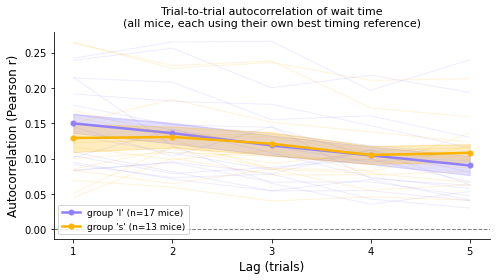

In [41]:

# ── Trial-to-trial autocorrelation of wait time (lag 1–5) ─────────────────────
LAGS = [1, 2, 3, 4, 5]
MIN_TRIALS = 10

GROUP_BEST_REF = {'l': 'cue_on', 's': 'last_lick'}

EXCLUDED_MICE = {'RZ069', 'RZ048', 'RZ084'}

# Each mouse uses their own best timing reference
mouse_best_col = {
    mouse: timing_refs[row['best_ref']]
    for mouse, row in mouse_pivot.iterrows()
    if row['best_ref'] in timing_refs
}

# All mice with a valid best reference, excluding specific mice
included_mice = set(mouse_best_col.keys()) - EXCLUDED_MICE
print(f"Mice included: {len(included_mice)} total  (excluded: {EXCLUDED_MICE})")
for grp in sorted(mouse_pivot['group'].dropna().unique()):
    n = sum(1 for m in included_mice if mouse_pivot.loc[m, 'group'] == grp)
    print(f"  group '{grp}': n={n}")

acf_rows = []
for mouse, mdf in trials.groupby('mouse'):
    if mouse not in included_mice:
        continue
    col = mouse_best_col.get(mouse)
    if col is None:
        continue
    grp = mdf['group'].iloc[0]
    for session, sdf in mdf.groupby('dir'):
        s = sdf.sort_values('session_trial_num')[col].dropna()
        s = s[s > 0]
        if len(s) < MIN_TRIALS:
            continue
        for lag in LAGS:
            acf_val = s.autocorr(lag=lag)
            acf_rows.append({'mouse': mouse, 'group': grp, 'dir': session,
                             'lag': lag, 'autocorr': acf_val})

acf_df = pd.DataFrame(acf_rows)

# Median per mouse across sessions
mouse_acf = (
    acf_df.groupby(['mouse', 'group', 'lag'])['autocorr']
    .median()
    .reset_index()
)

# Print summary
print("\nMean ± SEM autocorrelation by group and lag:")
summary = (
    mouse_acf.groupby(['group', 'lag'])['autocorr']
    .agg(['mean', 'sem', 'count'])
    .round(4)
)
print(summary.to_string())

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
for grp in groups:
    gdf = mouse_acf[mouse_acf['group'] == grp]
    color = group_palette[grp]
    for mouse, mdf in gdf.groupby('mouse'):
        ax.plot(mdf['lag'], mdf['autocorr'], color=color, alpha=0.15, lw=1)
    stats = gdf.groupby('lag')['autocorr'].agg(['mean', 'sem'])
    ax.plot(stats.index, stats['mean'], color=color, lw=2.5,
            marker='o', ms=5,
            label=f"group '{grp}' (n={gdf['mouse'].nunique()} mice)")
    ax.fill_between(stats.index,
                    stats['mean'] - stats['sem'],
                    stats['mean'] + stats['sem'],
                    color=color, alpha=0.25)

ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.set_xticks(LAGS)
ax.set_xlabel('Lag (trials)', fontsize=12)
ax.set_ylabel('Autocorrelation (Pearson r)', fontsize=12)
ax.set_title('Trial-to-trial autocorrelation of wait time\n(all mice, each using their own best timing reference)', fontsize=11)
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'wait_time_autocorrelation.png'), dpi=150, bbox_inches='tight')


Lag-1 autocorr & mean Δwait by group × N-1 reward (per block, consecutive non-miss pairs):

  mean_delta:
                    mean     sem  count
group outcome                          
l     rewarded   -0.7316  0.1635     17
      unrewarded  0.6143  0.1614     17
s     rewarded   -1.2771  0.2059     13
      unrewarded  0.7336  0.1501     13

  r:
                    mean     sem  count
group outcome                          
l     rewarded    0.1518  0.0129     17
      unrewarded  0.1062  0.0077     17
s     rewarded    0.1615  0.0253     13
      unrewarded  0.2148  0.0398     13


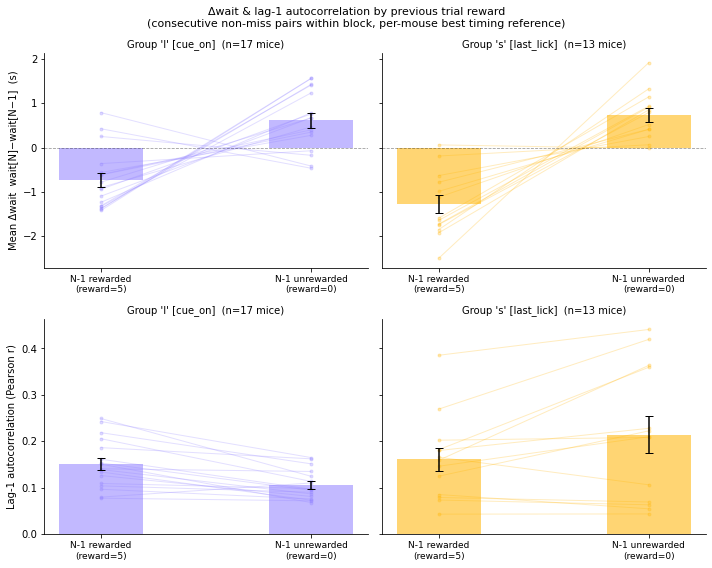

In [42]:
# ── Lag-1 autocorr & delta wait, split by N-1 reward outcome ──────────────────
# Consecutive pairs within each block (block_trial_num diff = 1).
# Both N-1 and N must be non-miss hits with valid wait times.
# Split by N-1 reward: 0 = unrewarded hit, 5 = rewarded hit.
# Inclusion: all mice compliant with group best ref (defined above, no bimodal filter)

MIN_PAIRS = 5

valid_dirs = set(trials['dir'].unique())
tt = trials_training[trials_training['dir'].isin(valid_dirs)].copy()

block_rows = []
for mouse, mdf_all in tt.groupby('mouse'):
    if mouse not in included_mice:
        continue
    col = mouse_best_col.get(mouse)
    if col is None:
        continue
    grp = mdf_all['group'].iloc[0]

    for (session, block_num), sdf in mdf_all.groupby(['dir', 'block_num']):
        sdf = sdf.sort_values('block_trial_num').reset_index(drop=True)

        pairs = {'rewarded': [], 'unrewarded': []}

        for i in range(1, len(sdf)):
            prev_row = sdf.iloc[i - 1]
            curr_row = sdf.iloc[i]

            # Must be truly consecutive within the block
            if curr_row['block_trial_num'] - prev_row['block_trial_num'] != 1:
                continue

            # N-1: non-miss, valid wait time
            w_prev = prev_row[col] if col in prev_row.index else np.nan
            if bool(prev_row['miss_trial']) or pd.isna(w_prev) or float(w_prev) <= 0:
                continue

            # N: non-miss, valid wait time
            w_curr = curr_row[col] if col in curr_row.index else np.nan
            if bool(curr_row['miss_trial']) or pd.isna(w_curr) or float(w_curr) <= 0:
                continue

            outcome = 'rewarded' if prev_row['reward'] > 0 else 'unrewarded'
            pairs[outcome].append((float(w_prev), float(w_curr)))

        for outcome, pts in pairs.items():
            if len(pts) < MIN_PAIRS:
                continue
            x = np.array([p[0] for p in pts])
            y = np.array([p[1] for p in pts])
            block_rows.append({
                'mouse':      mouse,
                'group':      grp,
                'dir':        session,
                'block_num':  block_num,
                'outcome':    outcome,
                'r':          float(np.corrcoef(x, y)[0, 1]),
                'mean_delta': float(np.mean(y - x)),
                'n_pairs':    len(pts),
            })

block_df = pd.DataFrame(block_rows)

# Median per mouse across blocks
mouse_block = (
    block_df.groupby(['mouse', 'group', 'outcome'])[['r', 'mean_delta']]
    .median()
    .reset_index()
)

print("Lag-1 autocorr & mean Δwait by group × N-1 reward (per block, consecutive non-miss pairs):")
for metric in ['mean_delta', 'r']:
    print(f"\n  {metric}:")
    print(mouse_block.groupby(['group', 'outcome'])[metric]
          .agg(['mean', 'sem', 'count']).round(4).to_string())

# Paired line plot — delta on top, autocorr on bottom
outcomes = ['rewarded', 'unrewarded']
x_pos = {'rewarded': 0, 'unrewarded': 1}

metrics = [
    ('mean_delta', 'Mean Δwait  wait[N]−wait[N−1]  (s)'),
    ('r',          'Lag-1 autocorrelation (Pearson r)'),
]

groups_present = sorted(mouse_block['group'].unique())
fig, axes = plt.subplots(2, len(groups_present), figsize=(5 * len(groups_present), 8), sharey='row')
if len(groups_present) == 1:
    axes = axes.reshape(-1, 1)

for row_i, (metric, ylabel) in enumerate(metrics):
    for col_i, grp in enumerate(groups_present):
        ax = axes[row_i, col_i]
        gdf = mouse_block[mouse_block['group'] == grp]
        color = group_palette[grp]

        # Individual mouse paired lines
        for mouse, mdf in gdf.groupby('mouse'):
            mdf_idx = mdf.set_index('outcome').reindex(outcomes)
            if mdf_idx[metric].isna().any():
                continue
            ax.plot([x_pos[o] for o in outcomes], mdf_idx[metric].values,
                    color=color, alpha=0.25, lw=1, marker='o', ms=3)

        # Mean ± SEM bars
        for o in outcomes:
            vals = gdf[gdf['outcome'] == o][metric].dropna()
            ax.bar(x_pos[o], vals.mean(), color=color, alpha=0.55, width=0.4, zorder=2)
            ax.errorbar(x_pos[o], vals.mean(), yerr=vals.sem(),
                        color='black', capsize=4, lw=1.5, zorder=3)

        ref_label = GROUP_BEST_REF.get(grp, '')
        ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['N-1 rewarded\n(reward=5)', 'N-1 unrewarded\n(reward=0)'], fontsize=9)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f"Group '{grp}' [{ref_label}]  (n={gdf['mouse'].nunique()} mice)", fontsize=10)
        sns.despine(ax=ax)

fig.suptitle('Δwait & lag-1 autocorrelation by previous trial reward\n'
             '(consecutive non-miss pairs within block, per-mouse best timing reference)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'delta_wait_and_autocorr_by_prev_reward.png'), dpi=150, bbox_inches='tight')
plt.show()


Group 'l': anchor='cue_on'  col=time_waited_since_cue_on  n=282,817
Group 's': anchor='last_lick'  col=time_waited_since_last_lick  n=276,301

── Excess ΔT summary (R2M method A, 95% CI) ──

  Group 'l'  (anchor: 'cue_on')
    rewarded        n=119,021  excess ΔT = +1358.4 ms  [+1322.6, +1394.1]  Wilcoxon p=0.000e+00
    not_rewarded    n=162,912  excess ΔT = +1014.3 ms  [+989.3, +1039.3]  Wilcoxon p=0.000e+00

  Group 's'  (anchor: 'last_lick')
    rewarded        n=92,024  excess ΔT = -242.0 ms  [-283.2, -200.9]  Wilcoxon p=0.000e+00
    not_rewarded    n=183,595  excess ΔT = +721.6 ms  [+701.3, +742.0]  Wilcoxon p=0.000e+00


/var/folders/fv/h96g2bdx42l2htl2pxpvr84h0000gn/T/ipykernel_4376/2292527832.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/fv/h96g2bdx42l2htl2pxpvr84h0000gn/T/ipykernel_4376/2292527832.py:133: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/fv/h96g2bdx42l2htl2pxpvr84h0000gn/T/ipykernel_4376/2292527832.py:181: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


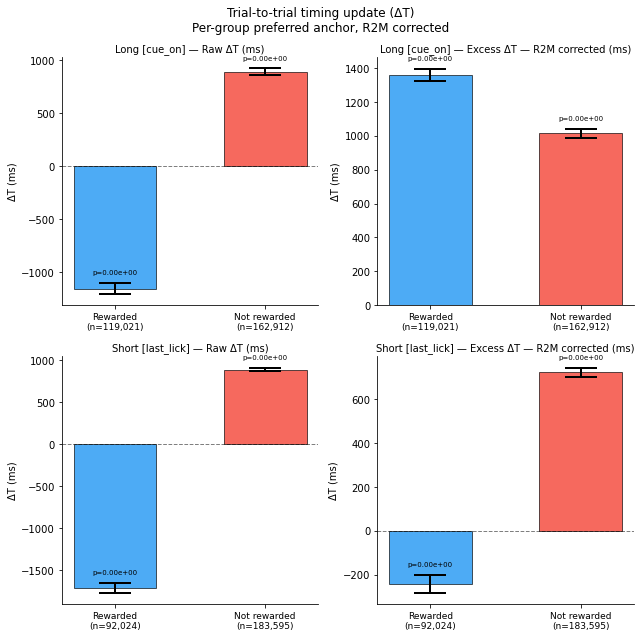

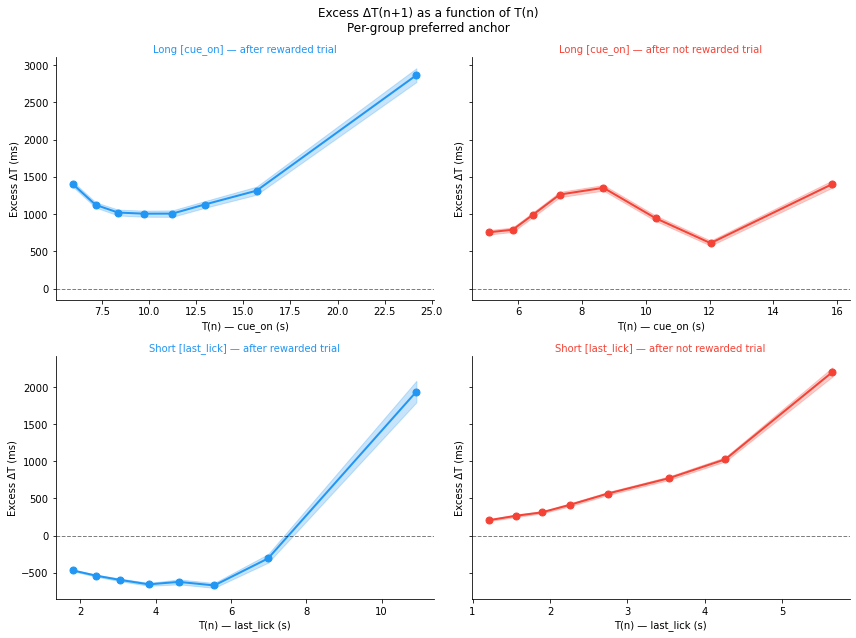

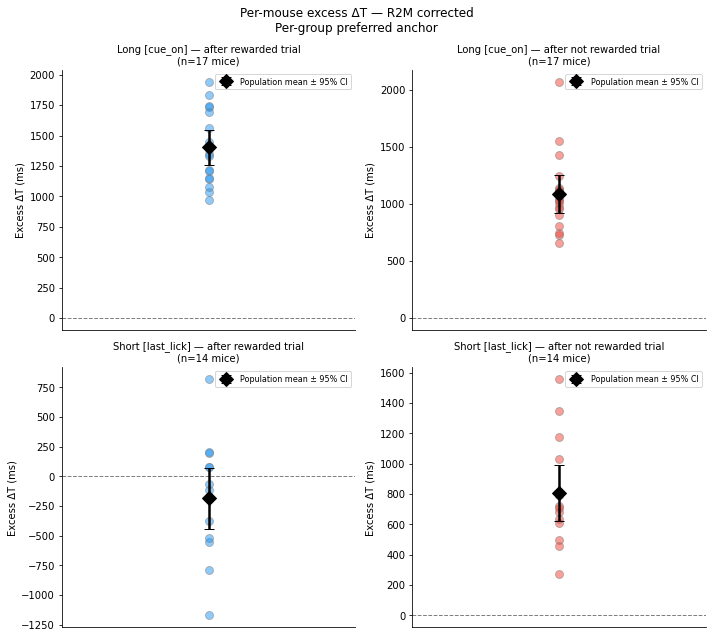

In [43]:
# ── ΔT analysis (Hamilos framework) — per-group preferred anchor ─────────────
# Ports delta_t_analysis.py into the notebook with R2M correction.
# Group 'l' → time_waited_since_cue_on
# Group 's' → time_waited_since_last_lick
#
# Pipeline per group:
#   1. ΔT(n+1) = T(n+1) - T(n) within session (by trial order)
#   2. R2M correction (method A: decile medians within block)
#   3. excess_delta_t = delta_t - r2m
#   4. Bootstrap 95% CI on mean excess ΔT, stratified by N outcome
# ─────────────────────────────────────────────────────────────────────────────

import importlib, sys
sys.path.insert(0, os.path.dirname(os.path.abspath('4_lick_detection.py')) if os.path.exists('4_lick_detection.py')
                else '/Users/rebekahzhang/Documents/shuler_lab/code/luckycharm')
import delta_t_analysis as dta
importlib.reload(dta)

GROUP_ANCHOR = {'l': 'cue_on', 's': 'last_lick'}

# ── Derive outcome column if not present ─────────────────────────────────────
if 'outcome' not in trials.columns:
    trials = dta.derive_outcome(trials)
else:
    # re-derive to make sure it reflects current data
    trials = dta.derive_outcome(trials)

# ── Process each group with its preferred anchor ──────────────────────────────
processed_parts = []
for grp in groups:
    anchor  = GROUP_ANCHOR[grp]
    col     = dta.TIMING_REFS[anchor]
    dta.COLUMN_MAP['wait_time'] = col
    dta.TIMING_ANCHOR           = anchor

    grp_df = trials[trials['group'] == grp].dropna(subset=[col])
    if len(grp_df) < 10:
        print(f"  Skipping group '{grp}' — not enough data")
        continue
    print(f"Group '{grp}': anchor={anchor!r}  col={col}  n={len(grp_df):,}")
    grp_processed = dta.process_all_sessions(grp_df, r2m_method='A')
    grp_processed['anchor'] = anchor
    processed_parts.append(grp_processed)

processed_dt = pd.concat(processed_parts, ignore_index=True)

# Add a unified 't_n' column (the anchor value used for each group)
# so plot functions that need T(n) on the x-axis can use one column name
processed_dt['t_n'] = np.nan
for grp in groups:
    col  = dta.TIMING_REFS[GROUP_ANCHOR[grp]]
    mask = processed_dt['group'] == grp
    if col in processed_dt.columns:
        processed_dt.loc[mask, 't_n'] = processed_dt.loc[mask, col]

# ── Print summary stats ───────────────────────────────────────────────────────
print("\n── Excess ΔT summary (R2M method A, 95% CI) ──")
for grp in groups:
    anchor = GROUP_ANCHOR[grp]
    gdf    = processed_dt[processed_dt['group'] == grp]
    print(f"\n  Group '{grp}'  (anchor: {anchor!r})")
    for label in [dta.REWARDED_LABEL, dta.NOT_REWARDED_LABEL]:
        mask = (gdf['outcome'] == label) & gdf['delta_t'].notna()
        vals = gdf.loc[mask, 'excess_delta_t'].values
        mean, lo, hi = dta.bootstrap_mean_ci(vals)
        from scipy import stats as _stats
        clean = vals[~np.isnan(vals)]
        _, pval = _stats.wilcoxon(clean) if len(clean) > 10 else (np.nan, np.nan)
        print(f"    {label:<15} n={mask.sum():>6,}  "
              f"excess ΔT = {mean*1000:+6.1f} ms  [{lo*1000:+6.1f}, {hi*1000:+6.1f}]  "
              f"Wilcoxon p={pval:.3e}")

# ── Figure 1: bar chart — raw & excess ΔT per outcome per group ───────────────
dta.COLUMN_MAP['wait_time'] = 't_n'
fig1, axes1 = plt.subplots(len(groups), 2, figsize=(9, 4.5 * len(groups)), squeeze=False)
fig1.suptitle('Trial-to-trial timing update (ΔT)\nPer-group preferred anchor, R2M corrected')

for row, grp in enumerate(groups):
    gdf         = processed_dt[processed_dt['group'] == grp]
    grp_results = dta._compute_summary_stats(gdf)
    grp_label   = dta.GROUP_LABELS.get(grp, grp)
    anchor      = GROUP_ANCHOR[grp]
    for col, (key, title) in enumerate([
        ('raw_mean',    'Raw ΔT (ms)'),
        ('excess_mean', 'Excess ΔT — R2M corrected (ms)'),
    ]):
        ax = axes1[row, col]
        dta._draw_bar_panel(ax, grp_results, key, f"{grp_label} [{anchor}] — {title}")

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'delta_t_summary_preferred_anchor.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: excess ΔT vs T(n), binned ───────────────────────────────────────
outcome_col = dta.COLUMN_MAP['outcome']
fig2, axes2 = plt.subplots(len(groups), 2, figsize=(12, 4.5 * len(groups)),
                           sharey='row', squeeze=False)
fig2.suptitle('Excess ΔT(n+1) as a function of T(n)\nPer-group preferred anchor')

for row, grp in enumerate(groups):
    anchor    = GROUP_ANCHOR[grp]
    grp_label = dta.GROUP_LABELS.get(grp, grp)
    gdf       = processed_dt[processed_dt['group'] == grp]

    for col, label in enumerate([dta.REWARDED_LABEL, dta.NOT_REWARDED_LABEL]):
        ax  = axes2[row, col]
        clr = dta.OUTCOME_COLORS[label]
        sub = gdf.loc[(gdf[outcome_col] == label) & gdf['delta_t'].notna()].copy()

        if len(sub) < 20:
            ax.set_title(f'{grp_label} — {label} — insufficient data')
            continue
        try:
            sub['t_bin']  = pd.qcut(sub['t_n'], q=8, duplicates='drop')
            bin_centers   = sub.groupby('t_bin')['t_n'].median()
            bin_means     = sub.groupby('t_bin')['excess_delta_t'].mean() * 1000
            bin_sems      = sub.groupby('t_bin')['excess_delta_t'].sem()  * 1000
            ax.plot(bin_centers, bin_means, 'o-', color=clr, linewidth=2, markersize=7)
            ax.fill_between(bin_centers, bin_means - bin_sems, bin_means + bin_sems,
                            alpha=0.25, color=clr)
        except Exception as e:
            ax.text(0.5, 0.5, f'Binning error:\n{e}', transform=ax.transAxes, ha='center')

        ax.axhline(0, color='k', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel(f"T(n) — {anchor} (s)", fontsize=10)
        ax.set_ylabel('Excess ΔT (ms)', fontsize=10)
        ax.set_title(f"{grp_label} [{anchor}] — after {label.replace('_', ' ')} trial",
                     fontsize=10, color=clr)
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'delta_t_by_Tn_preferred_anchor.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: per-mouse excess ΔT ─────────────────────────────────────────────
from scipy import stats as _stats
mouse_col = dta.COLUMN_MAP['mouse_id']
fig3, axes3 = plt.subplots(len(groups), 2, figsize=(10, 4.5 * len(groups)), squeeze=False)
fig3.suptitle('Per-mouse excess ΔT — R2M corrected\nPer-group preferred anchor')

for row, grp in enumerate(groups):
    anchor    = GROUP_ANCHOR[grp]
    grp_label = dta.GROUP_LABELS.get(grp, grp)
    gdf       = processed_dt[processed_dt['group'] == grp]
    mice      = gdf[mouse_col].unique()

    for col, label in enumerate([dta.REWARDED_LABEL, dta.NOT_REWARDED_LABEL]):
        ax          = axes3[row, col]
        clr         = dta.OUTCOME_COLORS[label]
        mouse_means = []

        for mouse in mice:
            sub = gdf.loc[
                (gdf[mouse_col] == mouse) &
                (gdf[outcome_col] == label) &
                gdf['excess_delta_t'].notna(),
                'excess_delta_t'
            ].values * 1000
            if len(sub) > 5:
                mouse_means.append(sub.mean())
                ax.plot(0, sub.mean(), 'o', color=clr, alpha=0.5, markersize=8, markeredgecolor='gray')

        if mouse_means:
            pop_mean = np.mean(mouse_means)
            pop_sem  = _stats.sem(mouse_means)
            ax.errorbar(0, pop_mean, yerr=pop_sem * 1.96,
                        fmt='D', color='k', markersize=10, linewidth=2.5,
                        capsize=5, label='Population mean ± 95% CI', zorder=5)

        ax.axhline(0, color='k', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([])
        ax.set_ylabel('Excess ΔT (ms)', fontsize=10)
        ax.set_title(f"{grp_label} [{anchor}] — after {label.replace('_', ' ')} trial"
                     f"\n(n={len(mouse_means)} mice)", fontsize=10)
        ax.legend(fontsize=8)
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'delta_t_per_mouse_preferred_anchor.png'), dpi=150, bbox_inches='tight')
plt.show()

Mice with REVERSE tendency (wait longer after rewarded, shorter after unrewarded):
mouse group  rewarded  unrewarded  delta_diff
RZ075     l  0.251564   -0.172671    0.424235
RZ057     l  0.425735   -0.464773    0.890508
RZ082     l  0.789689   -0.415158    1.204847
RZ083     s  0.061334   -0.017984    0.079317

Total reverse: 4 / 30  (13%)


/var/folders/fv/h96g2bdx42l2htl2pxpvr84h0000gn/T/ipykernel_4376/1904842124.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


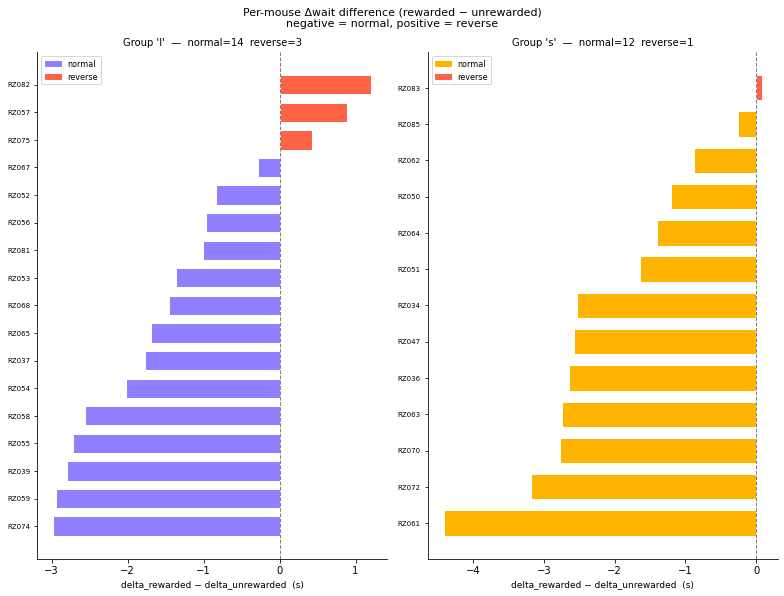

In [44]:

# ── Identify mice with reverse tendency ───────────────────────────────────────
# Normal: delta_rewarded < delta_unrewarded (shorter after reward, longer after non-reward)
# Reverse: delta_rewarded > delta_unrewarded

pivot = mouse_block.pivot(index=['mouse', 'group'], columns='outcome', values='mean_delta').reset_index()
pivot = pivot.dropna(subset=['rewarded', 'unrewarded'])
pivot['delta_diff'] = pivot['rewarded'] - pivot['unrewarded']  # negative = normal, positive = reverse
pivot['tendency'] = pivot['delta_diff'].apply(lambda x: 'reverse' if x > 0 else 'normal')
pivot = pivot.sort_values(['group', 'delta_diff'])

print("Mice with REVERSE tendency (wait longer after rewarded, shorter after unrewarded):")
rev = pivot[pivot['tendency'] == 'reverse'][['mouse', 'group', 'rewarded', 'unrewarded', 'delta_diff']]
print(rev.to_string(index=False))
print(f"\nTotal reverse: {len(rev)} / {len(pivot)}  ({len(rev)/len(pivot):.0%})")

# Horizontal bar chart of delta_diff per mouse, sorted within group
fig, axes = plt.subplots(1, 2, figsize=(11, max(4, len(pivot) * 0.28)), sharey=False)

for ax, grp in zip(axes, groups):
    gdf = pivot[pivot['group'] == grp].sort_values('delta_diff')
    colors = [group_palette[grp] if t == 'normal' else 'tomato' for t in gdf['tendency']]
    ax.barh(range(len(gdf)), gdf['delta_diff'], color=colors, edgecolor='white', height=0.7)
    ax.axvline(0, color='black', lw=1, linestyle='--', alpha=0.5)
    ax.set_yticks(range(len(gdf)))
    ax.set_yticklabels(gdf['mouse'], fontsize=7)
    ax.set_xlabel('delta_rewarded − delta_unrewarded  (s)', fontsize=9)
    ax.set_title(f"Group '{grp}'  —  normal={(gdf['tendency']=='normal').sum()}  "
                 f"reverse={(gdf['tendency']=='reverse').sum()}", fontsize=10)
    ax.legend(handles=[Patch(color=group_palette[grp], label='normal'),
                       Patch(color='tomato', label='reverse')], fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('Per-mouse Δwait difference (rewarded − unrewarded)\n'
             'negative = normal, positive = reverse', fontsize=11)
plt.tight_layout()
plt.show()


Mice in analysis: 30

Mean Δwait & lag-1 r by group × trial_type × outcome:

  mean_delta:
                                mean     sem  count
group trial_type  outcome                          
l     aim_for_end rewarded    3.2673  0.2799     17
                  unrewarded  3.3847  0.0904     17
      true_timing rewarded   -3.2433  0.3949     17
                  unrewarded -2.4777  0.2628     17
s     aim_for_end rewarded    0.0259  0.2790     12
                  unrewarded  1.3918  0.3044     12
      true_timing rewarded   -1.8632  0.1607     12
                  unrewarded  0.3648  0.0932     12

  r:
                                mean     sem  count
group trial_type  outcome                          
l     aim_for_end rewarded    0.0190  0.0142     17
                  unrewarded  0.0541  0.0116     17
      true_timing rewarded    0.1023  0.0124     17
                  unrewarded  0.0891  0.0257     17
s     aim_for_end rewarded    0.0644  0.0239     12
                  u

/var/folders/fv/h96g2bdx42l2htl2pxpvr84h0000gn/T/ipykernel_4376/3216318136.py:135: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


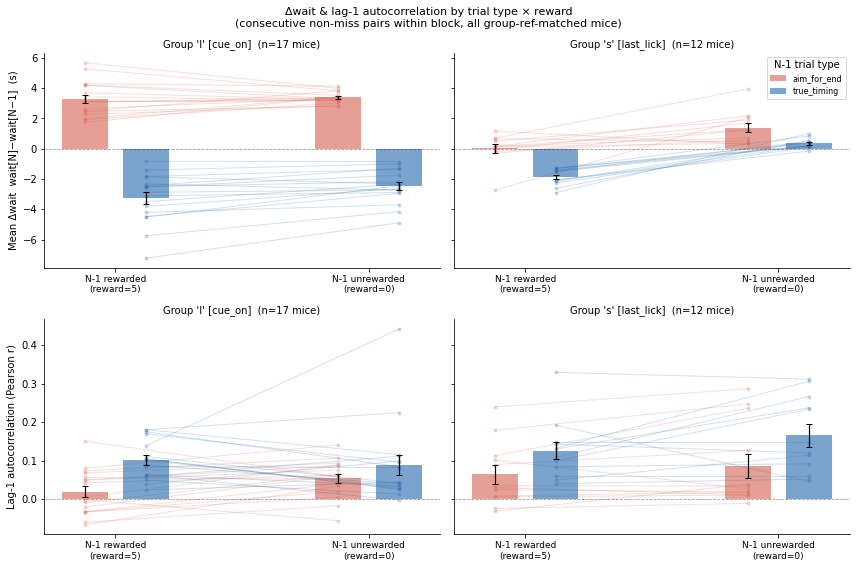

In [45]:
# ── Reward outcome × trial type (aim_for_end vs true_timing) ──────────────────
# Same consecutive non-miss hit pairs within blocks, but:
#   - N-1's trial_type used as the additional split dimension
#   - all mice compliant with group best ref (no bimodal restriction)
#   - mice without trial_type assigned will have NaN trial_type → skipped via ttype filter
# Tests RL hypothesis: does reward on a true_timing trial drive repetition more?

type_palette = {'aim_for_end': '#d6604d', 'true_timing': '#2166ac'}
trial_types  = ['aim_for_end', 'true_timing']
outcomes     = ['rewarded', 'unrewarded']

# Join trial_type from trials onto tt
type_map = trials[['dir', 'session_trial_num', 'trial_type']].dropna(subset=['trial_type'])
tt2 = tt.merge(type_map, on=['dir', 'session_trial_num'], how='left')

print(f"Mice in analysis: {len(included_mice)}")

block_rows2 = []
for mouse, mdf_all in tt2.groupby('mouse'):
    if mouse not in included_mice:
        continue
    col = mouse_best_col.get(mouse)
    if col is None:
        continue
    grp = mdf_all['group'].iloc[0]

    for (session, block_num), sdf in mdf_all.groupby(['dir', 'block_num']):
        sdf = sdf.sort_values('block_trial_num').reset_index(drop=True)

        pairs = {}  # (trial_type, outcome) → list of (w_prev, w_curr)

        for i in range(1, len(sdf)):
            prev_row = sdf.iloc[i - 1]
            curr_row = sdf.iloc[i]

            if curr_row['block_trial_num'] - prev_row['block_trial_num'] != 1:
                continue

            w_prev = prev_row[col] if col in prev_row.index else np.nan
            if bool(prev_row['miss_trial']) or pd.isna(w_prev) or float(w_prev) <= 0:
                continue

            w_curr = curr_row[col] if col in curr_row.index else np.nan
            if bool(curr_row['miss_trial']) or pd.isna(w_curr) or float(w_curr) <= 0:
                continue

            ttype = prev_row.get('trial_type', np.nan)
            if pd.isna(ttype) or ttype not in trial_types:
                continue

            outcome = 'rewarded' if prev_row['reward'] > 0 else 'unrewarded'
            key = (ttype, outcome)
            pairs.setdefault(key, []).append((float(w_prev), float(w_curr)))

        for (ttype, outcome), pts in pairs.items():
            if len(pts) < MIN_PAIRS:
                continue
            x = np.array([p[0] for p in pts])
            y = np.array([p[1] for p in pts])
            block_rows2.append({
                'mouse': mouse, 'group': grp, 'dir': session, 'block_num': block_num,
                'trial_type': ttype, 'outcome': outcome,
                'r': float(np.corrcoef(x, y)[0, 1]),
                'mean_delta': float(np.mean(y - x)),
                'n_pairs': len(pts),
            })

block_df2 = pd.DataFrame(block_rows2)

mouse_block2 = (
    block_df2.groupby(['mouse', 'group', 'trial_type', 'outcome'])[['r', 'mean_delta']]
    .median()
    .reset_index()
)

print("\nMean Δwait & lag-1 r by group × trial_type × outcome:")
for metric in ['mean_delta', 'r']:
    print(f"\n  {metric}:")
    print(mouse_block2.groupby(['group', 'trial_type', 'outcome'])[metric]
          .agg(['mean', 'sem', 'count']).round(4).to_string())

# Plot: 2 rows (metric) × 2 cols (group), hue = trial_type
x_pos  = {'rewarded': 0, 'unrewarded': 1}
tt_x   = {'aim_for_end': -0.12, 'true_timing': 0.12}
metrics = [
    ('mean_delta', 'Mean Δwait  wait[N]−wait[N−1]  (s)'),
    ('r',          'Lag-1 autocorrelation (Pearson r)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')

for row_i, (metric, ylabel) in enumerate(metrics):
    for col_i, grp in enumerate(['l', 's']):
        ax = axes[row_i, col_i]
        gdf = mouse_block2[mouse_block2['group'] == grp]
        color = group_palette[grp]

        for ttype in trial_types:
            tdf = gdf[gdf['trial_type'] == ttype]
            tc  = type_palette[ttype]
            offset = tt_x[ttype]

            for mouse, mdf in tdf.groupby('mouse'):
                mdf_idx = mdf.set_index('outcome').reindex(outcomes)
                if mdf_idx[metric].isna().any():
                    continue
                ax.plot([x_pos[o] + offset for o in outcomes], mdf_idx[metric].values,
                        color=tc, alpha=0.2, lw=1, marker='o', ms=3)

            for o in outcomes:
                vals = tdf[tdf['outcome'] == o][metric].dropna()
                if vals.empty:
                    continue
                xp = x_pos[o] + offset
                ax.bar(xp, vals.mean(), color=tc, alpha=0.6, width=0.18, zorder=2,
                       label=ttype if o == 'rewarded' else None)
                ax.errorbar(xp, vals.mean(), yerr=vals.sem(),
                            color='black', capsize=3, lw=1.2, zorder=3)

        ref_label = GROUP_BEST_REF.get(grp, '')
        ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['N-1 rewarded\n(reward=5)', 'N-1 unrewarded\n(reward=0)'], fontsize=9)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f"Group '{grp}' [{ref_label}]  (n={gdf['mouse'].nunique()} mice)", fontsize=10)
        if row_i == 0 and col_i == 1:
            ax.legend(title='N-1 trial type', fontsize=8)
        sns.despine(ax=ax)

fig.suptitle('Δwait & lag-1 autocorrelation by trial type × reward\n'
             '(consecutive non-miss pairs within block, all group-ref-matched mice)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'delta_wait_autocorr_by_trial_type_outcome.png'), dpi=150, bbox_inches='tight')
plt.show()


In [46]:
# ── Reward outcome × good_trial — R2M corrected excess ΔT ────────────────────
# Uses processed_dt from the new ΔT cell (R2M method A, per-group preferred anchor).
# Merges good_trial from trials, then computes per-mouse median excess ΔT
# stratified by (good_trial × N outcome).

good_trial_palette = {True: '#2ca02c', False: '#d62728'}
good_trial_vals    = [True, False]

# Merge good_trial onto processed_dt (match on mouse + dir + session_trial_num)
merge_cols = ['mouse', 'dir', 'session_trial_num', 'good_trial']
good_trial_lookup = trials[merge_cols].drop_duplicates()
pdt_gt = processed_dt.merge(good_trial_lookup, on=['mouse', 'dir', 'session_trial_num'], how='left')
pdt_gt['good_trial'] = pdt_gt['good_trial'].map(lambda x: bool(x) if pd.notna(x) else np.nan)

# Per-mouse median excess ΔT across sessions, stratified by (good_trial × outcome)
mouse_rows = []
for mouse, mdf in pdt_gt.groupby('mouse'):
    grp = mdf['group'].iloc[0]
    for gt in good_trial_vals:
        for label in ['rewarded', 'not_rewarded']:
            mask = (
                (mdf['good_trial'] == gt) &
                (mdf['outcome'] == label) &
                mdf['excess_delta_t'].notna()
            )
            vals = mdf.loc[mask, 'excess_delta_t'].values * 1000
            if len(vals) < MIN_PAIRS:
                continue
            mouse_rows.append({
                'mouse': mouse, 'group': grp,
                'good_trial': gt, 'outcome': label,
                'mean_excess_dt': float(np.mean(vals)),
                'n': len(vals),
            })

mouse_gt_df = pd.DataFrame(mouse_rows)

print("Excess ΔT (R2M corrected, ms) by group × good_trial × outcome:")
print(mouse_gt_df.groupby(['group', 'good_trial', 'outcome'])['mean_excess_dt']
      .agg(['mean', 'sem', 'count']).round(3).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
outcome_labels = ['rewarded', 'not_rewarded']
x_pos  = {'rewarded': 0, 'not_rewarded': 1}
gt_x   = {True: -0.12, False: 0.12}

fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 5), sharey=True)
if len(groups) == 1:
    axes = [axes]

for col_i, grp in enumerate(groups):
    ax     = axes[col_i]
    anchor = GROUP_ANCHOR[grp]
    gdf    = mouse_gt_df[mouse_gt_df['group'] == grp]

    for gt in good_trial_vals:
        tdf    = gdf[gdf['good_trial'] == gt]
        tc     = good_trial_palette[gt]
        offset = gt_x[gt]
        label  = f'good_trial={gt}'

        # Individual mouse paired lines
        for mouse, mdf in tdf.groupby('mouse'):
            mdf_idx = mdf.set_index('outcome').reindex(outcome_labels)
            if mdf_idx['mean_excess_dt'].isna().any():
                continue
            ax.plot([x_pos[o] + offset for o in outcome_labels],
                    mdf_idx['mean_excess_dt'].values,
                    color=tc, alpha=0.25, lw=1, marker='o', ms=3)

        # Mean ± SEM bars with bootstrap CI
        for o in outcome_labels:
            vals = tdf[tdf['outcome'] == o]['mean_excess_dt'].dropna().values
            if len(vals) == 0:
                continue
            xp       = x_pos[o] + offset
            mean, lo, hi = dta.bootstrap_mean_ci(vals)
            ax.bar(xp, mean, color=tc, alpha=0.65, width=0.18, zorder=2,
                   label=label if o == 'rewarded' else None)
            ax.plot([xp, xp], [lo, hi], color='black', lw=2, zorder=3)
            ax.plot([xp - 0.05, xp + 0.05], [lo, lo], color='black', lw=2, zorder=3)
            ax.plot([xp - 0.05, xp + 0.05], [hi, hi], color='black', lw=2, zorder=3)

    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['N rewarded', 'N not rewarded'], fontsize=9)
    ax.set_ylabel('Excess ΔT (ms)', fontsize=10)
    ax.set_title(f"Group '{grp}' [{anchor}]  (n={gdf['mouse'].nunique()} mice)", fontsize=10)
    ax.legend(title='N-1 good_trial', fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('R2M-corrected excess ΔT by good_trial × reward outcome\n'
             'Per-group preferred anchor, bootstrap 95% CI', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'delta_wait_autocorr_by_good_trial_outcome.png'), dpi=150, bbox_inches='tight')
plt.show()

KeyError: 'good_trial'

In [ ]:
# ── Excess ΔT stratified by trial_type (true_timing vs aim_for_end) ──────────
#
# Uses:
#   processed_dt  — from cell 59: R2M-corrected ΔT, per-group preferred anchor
#                   columns needed: mouse, group, dir, session_trial_num,
#                                   outcome, excess_delta_t, delta_t
#   trials        — from cell 55: has trial_type (GMM-assigned) + p_true_timing
#
# Design:
#   - N-1 trial_type is the split: we ask "given the N-1 trial was true_timing
#     or aim_for_end, how does the mouse update its wait time on trial N?"
#   - outcome is N-1 reward outcome (rewarded / not_rewarded)
#   - excess_delta_t is already R2M corrected (method A, block scope)
#   - Statistics: per-mouse mean excess ΔT → Wilcoxon test against zero
#     (conservative: one value per mouse, not pooled trials)
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns

# ── 0. Config ─────────────────────────────────────────────────────────────────
MIN_PAIRS     = 5      # minimum (trial_type, outcome) pairs per mouse to include
OUTCOME_COLS  = {'rewarded': '#2196F3', 'not_rewarded': '#F44336'}
TYPE_LABELS   = {'true_timing': 'True timing', 'aim_for_end': 'Aim for end'}
GROUP_PALETTE = {'s': '#ffb400', 'l': '#9080ff'}
GROUP_LABELS  = {'s': 'Short BG', 'l': 'Long BG'}

# ── 1. Merge trial_type onto processed_dt ─────────────────────────────────────
# trial_type reflects N-1 trial (the trial whose outcome drove the update)
type_lookup = (
    trials[['mouse', 'dir', 'session_trial_num', 'trial_type']]
    .dropna(subset=['trial_type'])
    .drop_duplicates()
)

# processed_dt already has session_trial_num for trial N.
# We want N-1 trial_type: shift session_trial_num by +1 to align N-1 label with N row.
# Equivalently: join on (mouse, dir, session_trial_num - 1) from the lookup.
pdt = processed_dt.copy()
pdt['prev_trial_num'] = pdt['session_trial_num'] - 1

type_lookup_prev = type_lookup.rename(columns={'session_trial_num': 'prev_trial_num',
                                                'trial_type': 'prev_trial_type'})
pdt = pdt.merge(type_lookup_prev, on=['mouse', 'dir', 'prev_trial_num'], how='left')

n_labeled   = pdt['prev_trial_type'].notna().sum()
n_total     = len(pdt)
print(f"Rows with N-1 trial_type assigned: {n_labeled:,} / {n_total:,} "
      f"({n_labeled / n_total:.1%})")
print(f"N-1 trial_type breakdown:\n{pdt['prev_trial_type'].value_counts().to_string()}\n")

# ── 2. Per-mouse mean excess ΔT by (group, trial_type, outcome) ───────────────
mouse_rows = []
groups_present = sorted(pdt['group'].dropna().unique())

for mouse, mdf in pdt.groupby('mouse'):
    grp = mdf['group'].iloc[0]
    for ttype in ['true_timing', 'aim_for_end']:
        for outcome_label in ['rewarded', 'not_rewarded']:
            mask = (
                (mdf['prev_trial_type'] == ttype) &
                (mdf['outcome'] == outcome_label) &
                mdf['excess_delta_t'].notna()
            )
            vals = mdf.loc[mask, 'excess_delta_t'].values * 1000  # → ms
            if len(vals) < MIN_PAIRS:
                continue
            mouse_rows.append({
                'mouse':          mouse,
                'group':          grp,
                'trial_type':     ttype,
                'outcome':        outcome_label,
                'mean_excess_dt': float(np.mean(vals)),
                'n_pairs':        len(vals),
            })

mouse_df = pd.DataFrame(mouse_rows)

print("Per-mouse summary (n mice with sufficient data):")
print(
    mouse_df.groupby(['group', 'trial_type', 'outcome'])
            .agg(n_mice=('mouse', 'count'),
                 mean_ms=('mean_excess_dt', 'mean'),
                 sem_ms=('mean_excess_dt', lambda x: stats.sem(x)))
            .round(2)
            .to_string()
)

# ── 3. Group-level Wilcoxon tests (per-mouse values vs zero) ──────────────────
print("\n\nWilcoxon tests (per-mouse means vs zero):")
print(f"{'group':<8} {'trial_type':<14} {'outcome':<14} {'n_mice':>7} "
      f"{'mean_ms':>9} {'SEM':>7} {'p':>10}")
print("-" * 72)

wilcox_results = {}
for (grp, ttype, outcome_label), sub in mouse_df.groupby(['group', 'trial_type', 'outcome']):
    vals = sub['mean_excess_dt'].values
    n    = len(vals)
    if n < 3:
        continue
    stat, p = stats.wilcoxon(vals)
    mean_ms  = vals.mean()
    sem_ms   = stats.sem(vals)
    wilcox_results[(grp, ttype, outcome_label)] = {'p': p, 'mean': mean_ms, 'sem': sem_ms, 'n': n}
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{grp:<8} {ttype:<14} {outcome_label:<14} {n:>7} "
          f"{mean_ms:>+9.1f} {sem_ms:>7.1f}  {p:>9.3e} {sig}")

# ── 4. Figure — per-mouse dots + population mean ± SEM ───────────────────────
# Layout: rows = groups (l, s), cols = trial_types (aim_for_end, true_timing)
# Within each panel: two bars (rewarded / not_rewarded) with per-mouse jitter

trial_types  = ['aim_for_end', 'true_timing']
outcome_list = ['rewarded', 'not_rewarded']
rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    len(groups_present), len(trial_types),
    figsize=(4 * len(trial_types), 4.5 * len(groups_present)),
    sharey='row', squeeze=False
)
fig.suptitle(
    'Excess ΔT by N-1 trial type × reward outcome\n'
    '(R2M corrected, method A; per-mouse means; error bars = SEM)',
    fontsize=12
)

for row, grp in enumerate(groups_present):
    grp_df    = mouse_df[mouse_df['group'] == grp]
    grp_label = GROUP_LABELS.get(grp, grp)

    for col, ttype in enumerate(trial_types):
        ax        = axes[row, col]
        type_df   = grp_df[grp_df['trial_type'] == ttype]
        type_label = TYPE_LABELS.get(ttype, ttype)

        x_positions = {o: i for i, o in enumerate(outcome_list)}
        bar_color   = GROUP_PALETTE.get(grp, '#888888')

        for outcome_label in outcome_list:
            x   = x_positions[outcome_label]
            sub = type_df[type_df['outcome'] == outcome_label]['mean_excess_dt'].values

            if len(sub) == 0:
                continue

            # Bar: population mean
            mean_val = sub.mean()
            sem_val  = stats.sem(sub) if len(sub) > 1 else 0
            clr      = OUTCOME_COLS[outcome_label]

            ax.bar(x, mean_val, width=0.5, color=clr, alpha=0.75,
                   edgecolor='k', linewidth=0.8, zorder=2)
            ax.errorbar(x, mean_val, yerr=sem_val * 1.96,
                        fmt='none', color='k', linewidth=2, capsize=5, zorder=3)

            # Per-mouse jitter
            jitter = rng.uniform(-0.12, 0.12, size=len(sub))
            ax.scatter(x + jitter, sub,
                       color=clr, edgecolors='k', linewidths=0.4,
                       s=30, alpha=0.7, zorder=4)

            # Wilcoxon p
            key = (grp, ttype, outcome_label)
            if key in wilcox_results:
                p   = wilcox_results[key]['p']
                sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                y_top = max(abs(mean_val) + sem_val * 1.96, np.max(np.abs(sub))) * 1.1
                y_top = y_top * np.sign(mean_val) if mean_val != 0 else y_top
                ax.text(x, mean_val + sem_val * 1.96 + 5, sig,
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax.axhline(0, color='k', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xticks(list(x_positions.values()))
        ax.set_xticklabels(
            [f"{o.replace('_', ' ').capitalize()}\n(n={len(type_df[type_df['outcome']==o])} mice)"
             for o in outcome_list],
            fontsize=9
        )
        ax.set_ylabel('Excess ΔT (ms)', fontsize=10)
        ax.set_title(f'{grp_label}  |  {type_label}', fontsize=10)
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'excess_dt_by_trial_type_and_outcome.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: excess_dt_by_trial_type_and_outcome.png")

# ── 5. Supplementary: ΔT(n+1) vs T(n) by trial_type ─────────────────────────
# Shows whether the shape of the update-vs-current-T curve differs by trial type

wait_col_by_group = {'l': 'time_waited', 's': 'time_waited'}

fig2, axes2 = plt.subplots(
    len(groups_present), len(trial_types),
    figsize=(5 * len(trial_types), 4.5 * len(groups_present)),
    squeeze=False
)
fig2.suptitle(
    'Excess ΔT vs T(n) by trial type\n'
    '(binned by T(n); shading = SEM; after unrewarded trials only)',
    fontsize=12
)

for row, grp in enumerate(groups_present):
    wait_col  = wait_col_by_group.get(grp, 'time_waited')
    grp_label = GROUP_LABELS.get(grp, grp)
    grp_pdt   = pdt[(pdt['group'] == grp) & (pdt['outcome'] == 'not_rewarded')].copy()

    for col, ttype in enumerate(trial_types):
        ax        = axes2[row, col]
        sub       = grp_pdt[grp_pdt['prev_trial_type'] == ttype].copy()
        type_label = TYPE_LABELS.get(ttype, ttype)

        if len(sub) < 20:
            ax.set_title(f'{grp_label} | {type_label} — insufficient data')
            continue

        try:
            sub['t_bin']    = pd.qcut(sub[wait_col], q=8, duplicates='drop')
            bin_centers     = sub.groupby('t_bin')[wait_col].median()
            bin_means       = sub.groupby('t_bin')['excess_delta_t'].mean() * 1000
            bin_sems        = sub.groupby('t_bin')['excess_delta_t'].sem()  * 1000
            bin_n           = sub.groupby('t_bin')['excess_delta_t'].count()

            clr = GROUP_PALETTE.get(grp, '#888')
            ax.plot(bin_centers, bin_means, 'o-', color=clr, linewidth=2, markersize=7)
            ax.fill_between(bin_centers,
                            bin_means - bin_sems,
                            bin_means + bin_sems,
                            alpha=0.25, color=clr)
        except Exception as e:
            ax.text(0.5, 0.5, f'Binning error:\n{e}', transform=ax.transAxes, ha='center')

        ax.axhline(0, color='k', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel(f'T(n) — wait time (s)', fontsize=10)
        ax.set_ylabel('Excess ΔT (ms)', fontsize=10)
        ax.set_title(f'{grp_label} | {type_label}\n(after unrewarded)', fontsize=10)
        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'excess_dt_vs_Tn_by_trial_type.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: excess_dt_vs_Tn_by_trial_type.png")

# splitting method 2
could try the 
Option B — Regression mixture model (the principled solution):
Fit a 2-component mixture where component membership is inferred jointly from the wait time distribution and the BG-wait relationship:

Component 1 (true timing): time_waited ~ N(μ₁, σ₁), no bg_length dependence
Component 2 (aim for end): time_waited ~ N(μ₂ - β·bg_length, σ₂), with β > 0

This is an EM regression mixture and is directly implementable. It's mechanistically constrained and gives per-trial posteriors. This is the strongest possible approach because it uses both the shape of the distribution and the BG-dependency simultaneously to assign labels.

# BG repeats stuff

In [ ]:
# ── Do true_timing trials have more bg_repeats = 0? ─────────────────────────
# Compare the proportion of bg_repeats==0 trials between true_timing and aim_for_end,
# per group, and plot the full bg_repeats distributions side by side.

from scipy.stats import mannwhitneyu, chi2_contingency

tt = trials.dropna(subset=['trial_type', 'bg_repeats'])

print("Proportion of bg_repeats == 0 by trial_type and group\n")
for grp in groups:
    g = tt[tt['group'] == grp]
    for ttype in ['true_timing', 'aim_for_end']:
        sub = g[g['trial_type'] == ttype]
        prop = (sub['bg_repeats'] == 0).mean()
        print(f"  Group '{grp}'  {ttype:<15}  n={len(sub):>5,}  bg_repeats==0: {prop:.1%}")

    # Chi-squared test: bg_repeats==0 vs >0, true_timing vs aim_for_end
    ct = pd.crosstab(g['trial_type'], g['bg_repeats'] == 0)
    if ct.shape == (2, 2):
        chi2, p, *_ = chi2_contingency(ct)
        print(f"  Group '{grp}'  chi2={chi2:.2f}  p={p:.4f}")
    print()

# --- Plot: bg_repeats distributions by trial_type, per group ---
BG_REPEAT_CUTOFF = {'s': 7, 'l': 15}
fig, axes = plt.subplots(2, len(groups), figsize=(7 * len(groups), 9))

for col_idx, grp in enumerate(groups):
    cutoff = BG_REPEAT_CUTOFF[grp]
    g = tt[(tt['group'] == grp) & (tt['bg_repeats'] <= cutoff)]

    # Top row: proportion of bg_repeats==0
    ax_prop = axes[0, col_idx]
    prop_df = (g.groupby('trial_type')
                .apply(lambda x: (x['bg_repeats'] == 0).mean())
                .rename('prop_zero')
                .reset_index())
    colors = {'true_timing': group_palette[grp], 'aim_for_end': '#aaaaaa'}
    bars = ax_prop.bar(prop_df['trial_type'], prop_df['prop_zero'],
                       color=[colors[t] for t in prop_df['trial_type']], alpha=0.8)
    ax_prop.set_ylabel('Proportion bg_repeats == 0', fontsize=11)
    ax_prop.set_title(f'Group "{grp}" — prop. zero bg repeats', fontsize=12)
    ax_prop.set_ylim(0, 1)
    ax_prop.grid(True, alpha=0.3, axis='y')
    sns.despine(ax=ax_prop)

    # Bottom row: full bg_repeats distribution as KDE
    ax_kde = axes[1, col_idx]
    for ttype, color in colors.items():
        sub = g[g['trial_type'] == ttype]['bg_repeats']
        if len(sub) < 2:
            continue
        sns.kdeplot(sub, ax=ax_kde, color=color, lw=2, label=ttype, fill=True, alpha=0.2)
    ax_kde.set_xlabel('bg_repeats', fontsize=11)
    ax_kde.set_ylabel('Density', fontsize=11)
    ax_kde.set_title(f'Group "{grp}" — bg_repeats distribution', fontsize=12)
    ax_kde.legend(fontsize=9)
    sns.despine(ax=ax_kde)

fig.suptitle('bg_repeats == 0 enrichment in true_timing vs aim_for_end trials',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'bg_repeats_zero_by_trial_type.png'), dpi=150, bbox_inches='tight')
plt.show()